# Section 0: Import Library

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# Section 1: Data Load & Cleaning

In [37]:
# data_2021 = pd.read_csv("./Dataset/verify_BC_datasets/2021/PM25_with_geo_2021.csv")
data_2022 = pd.read_csv("./Dataset/verify_BC_datasets/2022/PM25_with_geo_2022.csv")
data_2023 = pd.read_csv("./Dataset/verify_BC_datasets/2023/PM25_with_geo_2023.csv")
data_2024 = pd.read_csv("./Dataset/verify_BC_datasets/2024/PM25_with_geo_2024.csv")
data_2025 = pd.read_csv("./Dataset/verify_BC_datasets/2025/PM25_with_geo_2025.csv")

all_raw_dataframes = [data_2022, data_2023, data_2024, data_2025]

From the results below, I noticed that 2025 has much less data than the other years. We need further investigation. We also need to convert the data types into the correct datetime format.

In [38]:
# Check the datatype shape & info
for i, df in enumerate(all_raw_dataframes, start=2022):
    print(f"Year {i}: DataFrame shape: {df.shape}")
    print()
    print(df.info())

Year 2022: DataFrame shape: (1191360, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191360 entries, 0 to 1191359
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Datetime   1191360 non-null  object 
 1   Station    1191360 non-null  object 
 2   PM25       1105225 non-null  float64
 3   Latitude   1191360 non-null  float64
 4   Longitude  1191360 non-null  float64
dtypes: float64(3), object(2)
memory usage: 45.4+ MB
None
Year 2023: DataFrame shape: (1165080, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165080 entries, 0 to 1165079
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Datetime   1165080 non-null  object 
 1   Station    1165080 non-null  object 
 2   PM25       1029679 non-null  float64
 3   Latitude   1165080 non-null  float64
 4   Longitude  1165080 non-null  float64
dtypes: float64(3), object(2)
memory usage: 44

In [39]:
# Turn Datetime column into datetime type
for df in all_raw_dataframes:
    df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
    df["Station"] = df["Station"].astype(str)
    
    # print after conversion to check if it worked
    print(f"Year {df['Datetime'].dt.year.iloc[0]}:\n{df.dtypes}\n")

Year 2022:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object

Year 2023:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object

Year 2024:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object

Year 2025:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object



Here is the corrected and more natural version:

Check for duplicates in each year where the same date and the same station have different values. We keep the older record to ensure the data remains consistent. This logic makes sense if we consider the possibility that someone updated a value but forgot to remove the previous entry.

After removing duplicates, the results make more sense for 2022, 2023, and 2025, as they now have consistent values. However, 2024 still differs, which could be due to the leap year. As for 2021, the discrepancy might be because some stations do not have sufficient data. We need to identify those stations.

In [40]:
# Check the duplicate for each year
for i, df in enumerate(all_raw_dataframes, start=2022):
    duplicate_count = df.drop_duplicates(subset=['Datetime', 'Station'], keep="last").shape[0]
    print(f"Year {i}: Number of duplicate rows: {duplicate_count}")
    
        
    # remove duplicates
    df.drop_duplicates(subset=['Datetime', 'Station'], keep="last", inplace=True)
        
    # After removing duplicates, check how many rows are left.
    print(f"Year {i}: Number of rows after removing duplicates: {df.drop_duplicates().shape[0]}\n")



Year 2022: Number of duplicate rows: 551880
Year 2022: Number of rows after removing duplicates: 551880

Year 2023: Number of duplicate rows: 551880
Year 2023: Number of rows after removing duplicates: 551880

Year 2024: Number of duplicate rows: 553392
Year 2024: Number of rows after removing duplicates: 553392

Year 2025: Number of duplicate rows: 551880
Year 2025: Number of rows after removing duplicates: 551880



There are four stations—**Langdale Elementary**, **Quesnel Johnston Avenue**, **Sparwood Centennial Square**, and **Elkford Rocky Mountain Elementary School**—with late-starting data. We can remove them because they are from different regions in British Columbia, so dropping them should not significantly reduce coverage within any single region.


In [41]:
# # Find the earliest record time ("start date") for each station in 2021
# dataframe_2021 = all_raw_dataframes[0]  # DataFrame for year 2021
# station_start_dates = dataframe_2021.groupby("Station")["Datetime"].min().sort_values()

# print("--- 2021 Station Start Dates (Late Bloomers) ---")
# late_stations = station_start_dates[station_start_dates > pd.Timestamp("2021-01-02")]
# print(late_stations)
# print(f"{late_stations.index.tolist()}")


In [42]:
# # Remove all the data that came from those late-starting stations in all years
# late_station_names = late_stations.index.tolist()
# for df in all_raw_dataframes:
#     df.drop(df[df["Station"].isin(late_station_names)].index, inplace=True)

In [43]:
for i, df in enumerate(all_raw_dataframes, start=2022):
    print(f"\nYEAR: {i}")
    print(f"Records: {len(df)}")
    if not df.empty:
        print(f"Time Range: {df['Datetime'].min()} to {df['Datetime'].max()}")
        print(f"Missing Values Percentage: {df.isna().sum().sum() / df.size * 100:.2f}%")
        
        # print total unique stations after removing late bloomers
        print(f"Total Unique Stations: {df['Station'].nunique()}")



YEAR: 2022
Records: 551880
Time Range: 2022-01-01 01:00:00 to 2023-01-01 00:00:00
Missing Values Percentage: 1.21%
Total Unique Stations: 63

YEAR: 2023
Records: 551880
Time Range: 2023-01-01 01:00:00 to 2024-01-01 00:00:00
Missing Values Percentage: 1.82%
Total Unique Stations: 63

YEAR: 2024
Records: 553392
Time Range: 2024-01-01 01:00:00 to 2025-01-01 00:00:00
Missing Values Percentage: 0.68%
Total Unique Stations: 63

YEAR: 2025
Records: 551880
Time Range: 2025-01-01 01:00:00 to 2026-01-01 00:00:00
Missing Values Percentage: 1.33%
Total Unique Stations: 63


We would like to investigate the missing values. In this case, the total number of missing values could be misleading. If a station has significantly more missing data than other stations, it may need to be dropped.

In [44]:
# %% Check missing values by station
print("--- Missing PM2.5 Percentage by Station (> 0%) ---")

for i, df in enumerate(all_raw_dataframes, start=2022):
    
    # print year
    print(f"\nYEAR: {i}\n")
    
    # 1. Group by 'Station' and calculate the percentage of NaN values in 'PM25'
    # We use .isna().mean() * 100 to get the percentage
    missing_stats = df.groupby('Station')['PM25'].apply(lambda x: x.isna().mean() * 100)
    
    # 2. Filter: Keep only stations with > 0% missing data
    missing_stats = missing_stats[missing_stats > 0]
    
    # 3. Sort: From Big to Small (Descending)
    missing_stats = missing_stats.sort_values(ascending=False)
    
    # 4. Print the result
    if not missing_stats.empty:
        # Print with 2 decimal places and a % sign
        print(missing_stats.apply(lambda x: f"{x:.2f}%"))
    else:
        print("✅ No stations have missing PM2.5 values (NaNs) in the recorded rows.")
        
    print("\n" + "-"*50)

--- Missing PM2.5 Percentage by Station (> 0%) ---

YEAR: 2022

Station
Valemount                           68.49%
Victoria Topaz                      62.32%
Courtenay Elementary School         57.41%
Prince George Plaza 400             30.19%
Sparwood Centennial Square          14.16%
                                     ...  
Fort St John Key Learning Centre     0.41%
Vernon Science Centre                0.31%
Kamloops Federal Building            0.27%
Smithers Muheim Memorial             0.21%
Kelowna KLO Road                     0.16%
Name: PM25, Length: 63, dtype: object

--------------------------------------------------

YEAR: 2023

Station
Houston Firehall                87.00%
Victoria Topaz                  57.88%
Duncan College Street           55.32%
Colwood City Hall               51.99%
Valemount                       35.24%
                                 ...  
Abbotsford Central               0.64%
Tsawwassen                       0.42%
Abbotsford A Columbia Street    

Based on the results above, some stations have more than 20% missing data. In general, when more than 20% of a dataset is missing, it becomes difficult to impute reliably. Therefore, we will remove these stations for all years to ensure data consistency.

In [45]:
# %% Remove stations with > 20% missing data
print("--- Removing Stations with > 20% Missing Data ---")

# 1. Identify stations to remove
stations_to_remove = set()


for i, df in enumerate(all_raw_dataframes, start=2022):
    # Calculate missing percentage per station
    missing_series = df.groupby('Station')['PM25'].apply(lambda x: x.isna().mean())
    
    # Identify stations with > 20% missing
    bad_stations = missing_series[missing_series > 0.20].index.tolist()
    
    if bad_stations:
        print(f"Year {i}: Found {len(bad_stations)} stations with > 20% missing data.")
        stations_to_remove.update(bad_stations)

# 2. Print summary of stations to be removed
print(f"\n🚫 Total Unique Stations to Remove: {len(stations_to_remove)}")
print(f"Stations: {sorted(list(stations_to_remove))}")

# 3. Remove them from all datasets
if stations_to_remove:
    for i, df in enumerate(all_raw_dataframes, start=2022):
        original_count = len(df)
        original_count = len(df)
        
        # Filter out the bad stations
        # We use ~ (tilde) to negate the condition (Keep stations NOT in the remove list)
        all_raw_dataframes[i - 2022] = df[~df['Station'].isin(stations_to_remove)]
        
        dropped_count = original_count - len(all_raw_dataframes[i - 2022])
        print(f"✅ Year {i}: Dropped {dropped_count} rows (removed {len(stations_to_remove)} stations).")

# 4. Final check of remaining stations
if all_raw_dataframes:
    first_year = 2022
    remaining_stations = all_raw_dataframes[0]["Station"].nunique()
    print(f"\n🎉 Final Common Station Count: {remaining_stations}")

--- Removing Stations with > 20% Missing Data ---
Year 2022: Found 4 stations with > 20% missing data.
Year 2023: Found 7 stations with > 20% missing data.
Year 2024: Found 2 stations with > 20% missing data.
Year 2025: Found 3 stations with > 20% missing data.

🚫 Total Unique Stations to Remove: 13
Stations: ['Colwood City Hall', 'Courtenay Elementary School', 'Crofton Elementary', 'Duncan College Street', 'Duncan Deykin Avenue', 'Houston Firehall', 'Nanaimo Labieux Road', 'North Vancouver Second Narrows', 'Prince George Plaza 400', 'Quesnel Johnston Avenue', 'Terrace Skeena Middle School', 'Valemount', 'Victoria Topaz']
✅ Year 2022: Dropped 113880 rows (removed 13 stations).
✅ Year 2023: Dropped 113880 rows (removed 13 stations).
✅ Year 2024: Dropped 114192 rows (removed 13 stations).
✅ Year 2025: Dropped 113880 rows (removed 13 stations).

🎉 Final Common Station Count: 50


In [46]:
# %% Check missing values by station
print("--- Missing PM2.5 Percentage by Station (> 0%) ---")

for i, df in enumerate(all_raw_dataframes, start=2022):
    
    # print year
    print(f"\nYEAR: {i}\n")
    
    # 1. Group by 'Station' and calculate the percentage of NaN values in 'PM25'
    # We use .isna().mean() * 100 to get the percentage
    missing_stats = df.groupby('Station')['PM25'].apply(lambda x: x.isna().mean() * 100)
    
    # 2. Filter: Keep only stations with > 0% missing data
    missing_stats = missing_stats[missing_stats > 0]
    
    # 3. Sort: From Big to Small (Descending)
    missing_stats = missing_stats.sort_values(ascending=False)
    
    # 4. Print the result
    if not missing_stats.empty:
        # Print with 2 decimal places and a % sign
        print(missing_stats.apply(lambda x: f"{x:.2f}%"))
    else:
        print("✅ No stations have missing PM2.5 values (NaNs) in the recorded rows.")
        
    print("\n" + "-"*50)

--- Missing PM2.5 Percentage by Station (> 0%) ---

YEAR: 2022

Station
Sparwood Centennial Square                  14.16%
Elk Falls Dogwood                           12.58%
Whistler Meadow Park                        11.22%
Prince Rupert Fairview                       8.52%
Mission School Works Yard                    8.03%
Vanderhoof Courthouse                        6.16%
Kitimat Haul Road                            5.14%
Kitimat Haisla Village                       4.67%
Kitimat Whitesail                            3.92%
Fort St John North Camp C                    3.69%
Crofton Substation                           3.55%
Elkford Rocky Mountain Elementary School     3.53%
Harmac Cedar Woobank                         3.28%
Kitimat Riverlodge                           3.13%
Pitt Meadows Meadowlands School              3.06%
Hope Airport                                 2.76%
Surrey East                                  2.56%
Peace Valley Attachie Flat Upper Terrace     2.56%
Fort St Jo

## 1. Define Distance Metric

We first define the **Haversine Formula**, which calculates the precise "Great Circle" distance between two points on the Earth's surface. This is critical for accurate spatial weighting in high-latitude regions like BC.


In [47]:
def haversine_matrix(coords):
    """
    Calculates the Great Circle distance between multiple points on Earth.
    
    Args:
        coords: Numpy array of shape (N, 2) containing [[Lat, Lon], ...] in decimal degrees.
    
    Returns:
        N x N matrix of distances in Kilometers.
    """
    R = 6371.0  # Earth radius in kilometers
    
    # Convert degrees to radians
    rads = np.radians(coords)
    lat = rads[:, 0][:, np.newaxis]
    lon = rads[:, 1][:, np.newaxis]
    
    # Vectorized Haversine formula
    dlat = lat - lat.T
    dlon = lon - lon.T
    a = np.sin(dlat / 2)**2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


## 2. Define the Imputation Function

This is the core engine of the pipeline. It takes a single year's dataframe and applies the three-step imputation logic sequentially.


In [48]:
def rigorous_imputation_pipeline(df, year_label):
    """
    Executes the 3-stage imputation pipeline:
    1. Temporal Forward Fill (Limit=1hr) -> Fixes micro-gaps.
    2. Spatial IDW (Haversine) -> Fixes macro-gaps using neighbors.
    3. Linear Interpolation -> Final cleanup for network-wide outages.
    """
    df = df.copy()
    
    # Ensure Datetime is properly formatted and sorted
    df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
    df = df.sort_values(['Station', 'Datetime'])
    
    initial_missing = df['PM25'].isna().sum()
    if initial_missing == 0:
        print(f"[{year_label}] ✅ Data is already complete.")
        return df

    # --- Step 1: Temporal Forward Fill (Limit 1 hour) ---
    # We only fill gaps of 1 hour to preserve data integrity (no future data used).
    df['PM25'] = df.groupby('Station')['PM25'].ffill(limit=1)
    missing_s1 = df['PM25'].isna().sum()
    
    # --- Step 2: Spatial IDW (Haversine Distance) ---
    if missing_s1 > 0:
        # Pivot to wide format: Index=Time, Columns=Stations
        pivot = df.pivot_table(index='Datetime', columns='Station', values='PM25')
        
        # Prepare coordinates aligned with pivot columns
        stations_info = df[['Station', 'Latitude', 'Longitude']].drop_duplicates('Station').set_index('Station')
        stations_info = stations_info.loc[pivot.columns]
        coords = stations_info[['Latitude', 'Longitude']].values
        
        # Calculate Distance Matrix
        dists = haversine_matrix(coords)
        np.fill_diagonal(dists, np.inf) # Ignore self-distance
        
        # Calculate Weights (Inverse Distance Squared)
        weights = 1.0 / (dists + 1e-6)**2 
        
        # Vectorized Imputation
        values = pivot.values
        # Mask: 1 where data exists, 0 where NaN
        mask_present = (~np.isnan(values)).astype(float)
        values_zeroed = np.nan_to_num(values)
        
        # Weighted Average Calculation
        with np.errstate(divide='ignore', invalid='ignore'):
            numerator = values_zeroed @ weights.T
            denominator = mask_present @ weights.T
            imputed = numerator / denominator
        
        # Fill missing values in the pivot table
        pivot_filled = pivot.copy()
        mask_missing = pivot.isna()
        pivot_filled[mask_missing] = pd.DataFrame(imputed, index=pivot.index, columns=pivot.columns)[mask_missing]
        
        # Convert back to long format (melt) and merge
        df_filled = pivot_filled.reset_index().melt(id_vars='Datetime', var_name='Station', value_name='PM25_Filled')
        df = pd.merge(df, df_filled, on=['Datetime', 'Station'], how='left')
        
        # Apply the filled values
        df['PM25'] = df['PM25'].fillna(df['PM25_Filled'])
        df = df.drop(columns=['PM25_Filled'])
    
    missing_s2 = df['PM25'].isna().sum()

    # --- Step 3: Final Cleanup (Linear Interpolation) ---
    # Handles rare cases where ALL stations are down simultaneously (IDW fails).
    if missing_s2 > 0:
        df['PM25'] = df.groupby('Station')['PM25'].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )
    
    missing_final = df['PM25'].isna().sum()
    
    # Print Summary Stats
    print(f"[{year_label}] Imputation Stats:")
    print(f"   - Initial Missing: {initial_missing}")
    print(f"   - Recovered by S1 (Time):  {initial_missing - missing_s1}")
    print(f"   - Recovered by S2 (Space): {missing_s1 - missing_s2}")
    print(f"   - Recovered by S3 (Clean): {missing_s2 - missing_final}")
    print(f"   - Final Missing: {missing_final}")
    
    return df


## 3. Main Execution: Process 2022-2025

Here we iterate through the datasets. We first enforce spatial consistency by keeping only stations that exist in all four years (Common Stations).


In [49]:
# Configuration
years = [2022, 2023, 2024, 2025]
# Assuming 'all_raw_dataframes' is already loaded: [data_2022, data_2023, data_2024, data_2025]
cleaned_dfs = []

print("--- 1. Filtering for Common Stations ---")

# Identify stations present in ALL years
common_stations = set(all_raw_dataframes[0]['Station'].unique())
for df in all_raw_dataframes[1:]:
    common_stations &= set(df['Station'].unique())

print(f"Identified {len(common_stations)} common stations across 4 years.")

print("\n--- 2. Running Rigorous Imputation ---")

for i, df in enumerate(all_raw_dataframes):
    year = years[i]
    
    # Filter dataset to include only common stations
    df_target = df[df['Station'].isin(common_stations)].copy()
    
    # Run the imputation pipeline
    df_clean = rigorous_imputation_pipeline(df_target, str(year))
    cleaned_dfs.append(df_clean)

print("\nProcessing Complete.")


--- 1. Filtering for Common Stations ---
Identified 50 common stations across 4 years.

--- 2. Running Rigorous Imputation ---
[2022] Imputation Stats:
   - Initial Missing: 11655
   - Recovered by S1 (Time):  2402
   - Recovered by S2 (Space): 9253
   - Recovered by S3 (Clean): 0
   - Final Missing: 0
[2023] Imputation Stats:
   - Initial Missing: 17088
   - Recovered by S1 (Time):  2613
   - Recovered by S2 (Space): 14475
   - Recovered by S3 (Clean): 0
   - Final Missing: 0
[2024] Imputation Stats:
   - Initial Missing: 11854
   - Recovered by S1 (Time):  2273
   - Recovered by S2 (Space): 9581
   - Recovered by S3 (Clean): 0
   - Final Missing: 0
[2025] Imputation Stats:
   - Initial Missing: 15134
   - Recovered by S1 (Time):  2729
   - Recovered by S2 (Space): 12405
   - Recovered by S3 (Clean): 0
   - Final Missing: 0

Processing Complete.


## 4. Final Assembly and Validation

Finally, we combine all processed years into a single master dataset and verify that zero missing values remain.


In [50]:
# Combine all years into one DataFrame
full_imputed_data = pd.concat(cleaned_dfs, ignore_index=True).sort_values(['Datetime', 'Station'])

# Final Validation
print("--- Final Dataset Validation ---")
total_rows = len(full_imputed_data)
total_nans = full_imputed_data['PM25'].isna().sum()

print(f"Total Records: {total_rows}")
print(f"Time Range:    {full_imputed_data['Datetime'].min()} to {full_imputed_data['Datetime'].max()}")

if total_nans == 0:
    print("🎉 SUCCESS: The dataset is 100% complete with 0 missing values.")
else:
    print(f"⚠️ WARNING: There are still {total_nans} missing values. Please investigate.")

# Preview the clean data and sort by datetime and station for better readability
full_imputed_data.sort_values(['Datetime', 'Station'], inplace=True)

# Reset index for cleanliness
full_imputed_data.reset_index(drop=True, inplace=True)


full_imputed_data.head()

--- Final Dataset Validation ---
Total Records: 1753200
Time Range:    2022-01-01 01:00:00 to 2026-01-01 00:00:00
🎉 SUCCESS: The dataset is 100% complete with 0 missing values.


,Datetime,Station,PM25,Latitude,Longitude
0,2022-01-01 01:00:00,Abbotsford A Columbia Street,2.840752,49.021500,-122.326500
1,2022-01-01 01:00:00,Abbotsford Central,14.556050,49.042600,-122.309800
2,2022-01-01 01:00:00,Burnaby Kensington Park,11.800620,49.279200,-122.970700
3,2022-01-01 01:00:00,Burnaby South,3.421575,49.215200,-122.985700
4,2022-01-01 01:00:00,Burns Lake Fire Centre,3.517412,54.230731,-125.764354


In [51]:
full_imputed_data.to_csv("./Dataset/verify_BC_datasets/PM25_imputed_full_2022_2025.csv", index=False)

In [52]:
full_imputed_data.head()

,Datetime,Station,PM25,Latitude,Longitude
0,2022-01-01 01:00:00,Abbotsford A Columbia Street,2.840752,49.021500,-122.326500
1,2022-01-01 01:00:00,Abbotsford Central,14.556050,49.042600,-122.309800
2,2022-01-01 01:00:00,Burnaby Kensington Park,11.800620,49.279200,-122.970700
3,2022-01-01 01:00:00,Burnaby South,3.421575,49.215200,-122.985700
4,2022-01-01 01:00:00,Burns Lake Fire Centre,3.517412,54.230731,-125.764354


# Section 2: EDA

## Section 2.1: 1 Dimension Variable

In this section, we focus on the one dimension variable only.

In the following part, we wonly focus on how the date, weekly, monthly will affect the PM2.5.

### Section 2.1.1: Data Preparation & Feature Engineering
Before plotting, we need to extract time-based features from your datetime column. This step creates the foundation for all subsequent charts by calculating hours, days of the week, and defining "Weekend" vs. "Weekday".

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# ---------------------------------------------------------
# 1. Setup & Feature Engineering
# ---------------------------------------------------------
# Create a working copy of your dataframe
df = full_imputed_data.copy()

# Configuration: Update these if your column names differ
time_col = 'Datetime'  # The column containing date and time
val_col = 'PM25'       # The value column to visualize

# Ensure the time column is in datetime object format and sorted
df[time_col] = pd.to_datetime(df[time_col])
df.sort_values(by=time_col, inplace=True)

# Generate time-based features for grouping
df['hour'] = df[time_col].dt.hour
df['day_of_week'] = df[time_col].dt.day_name()
df['month'] = df[time_col].dt.month
df['year'] = df[time_col].dt.year

# Define "Day Type" to distinguish Weekends (Sat/Sun) from Weekdays
# .dayofweek: 0=Monday, 6=Sunday. We classify >= 5 as Weekend.
df['day_type'] = df[time_col].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Define a custom sort order for days so charts plot Mon->Sun instead of alphabetically
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

### Section 2.1.2: Micro-Analysis (Human Activity)
This section focuses on short-term patterns driven by human behavior.

    - Chart 1 (Daily Rhythm): Highlights "Rush Hours" (7-9 AM and 4-7 PM) in red to show traffic impact.

    - Chart 2 (Lifestyle): Compares the hourly curve of Weekdays vs. Weekends.

    - Chart 3 (Weekly Trend): Shows how pollution accumulates throughout the work week.

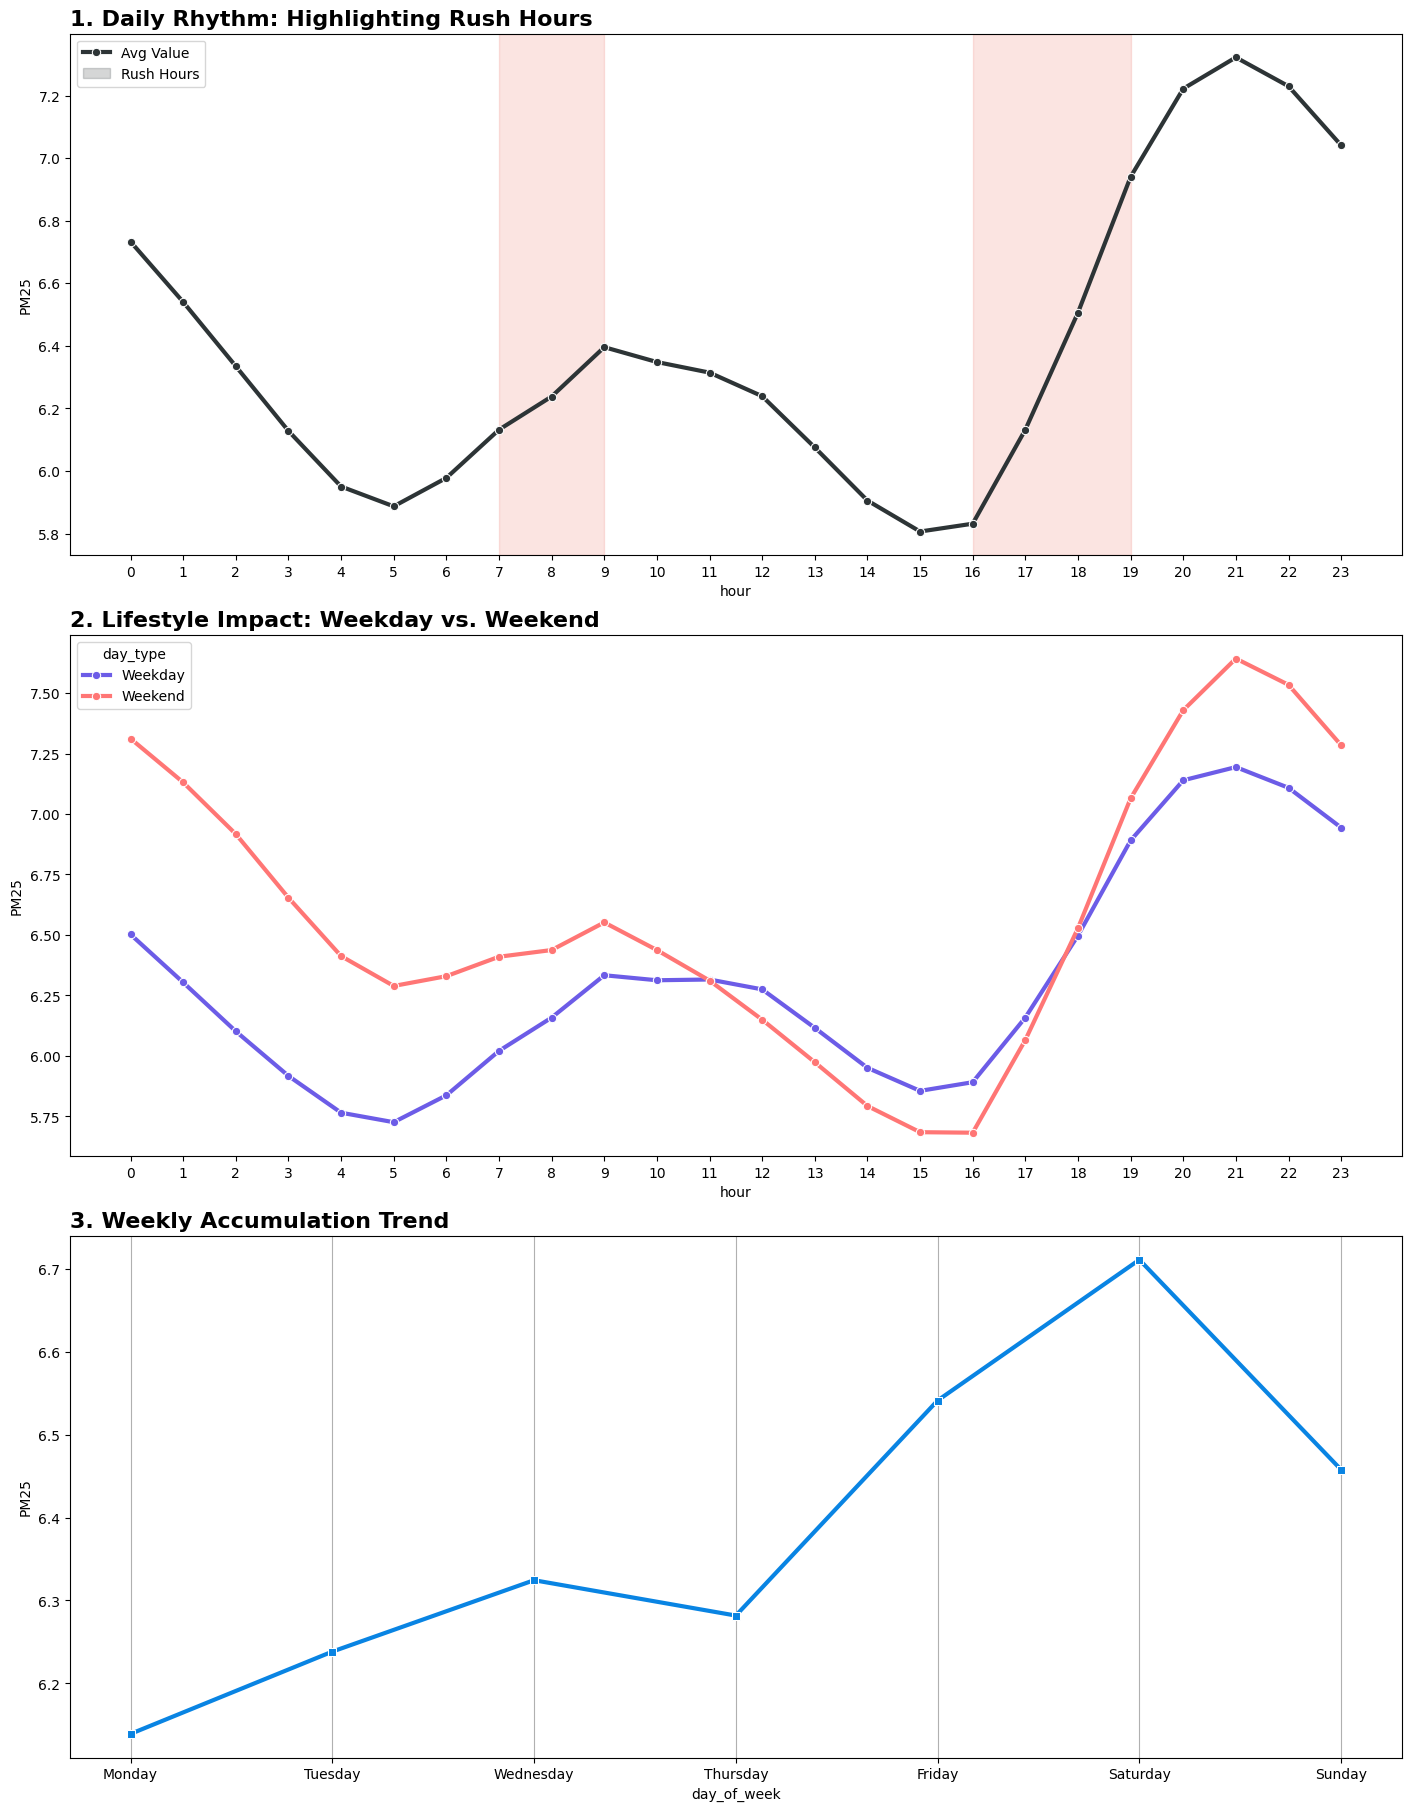

In [54]:
# ---------------------------------------------------------
# ACT 1: Micro-Analysis (Daily & Weekly Patterns)
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(3, 1, figsize=(14, 18), constrained_layout=True)

# --- Chart 1: Daily Cycle with Rush Hours ---
hourly_avg = df.groupby('hour')[val_col].mean().reset_index()

sns.lineplot(data=hourly_avg, x='hour', y=val_col, ax=axes1[0], 
             marker='o', color='#2d3436', linewidth=3, zorder=10)

# Highlight Rush Hours: Morning (7-9) and Evening (16-19)
axes1[0].axvspan(7, 9, color='#e74c3c', alpha=0.15, label='Rush Hour')
axes1[0].axvspan(16, 19, color='#e74c3c', alpha=0.15)
axes1[0].set_title('1. Daily Rhythm: Highlighting Rush Hours', fontsize=16, fontweight='bold', loc='left')
axes1[0].set_xticks(range(0, 24))
axes1[0].legend(['Avg Value', 'Rush Hours'], loc='upper left')

# --- Chart 2: Weekday vs. Weekend Comparison ---
split_avg = df.groupby(['hour', 'day_type'])[val_col].mean().reset_index()

sns.lineplot(data=split_avg, x='hour', y=val_col, hue='day_type', ax=axes1[1], 
             marker='o', palette={'Weekday': '#6c5ce7', 'Weekend': '#ff7675'}, linewidth=3)

axes1[1].set_title('2. Lifestyle Impact: Weekday vs. Weekend', fontsize=16, fontweight='bold', loc='left')
axes1[1].set_xticks(range(0, 24))

# --- Chart 3: Weekly Accumulation ---
# Reindex ensures the x-axis follows Monday -> Sunday order
weekly_avg = df.groupby('day_of_week')[val_col].mean().reindex(week_order).reset_index()

sns.lineplot(data=weekly_avg, x='day_of_week', y=val_col, ax=axes1[2], 
             marker='s', color='#0984e3', linewidth=3)

axes1[2].set_title('3. Weekly Accumulation Trend', fontsize=16, fontweight='bold', loc='left')
axes1[2].grid(True, axis='x')

plt.show()

3. Act 2: Macro-Analysis (Seasonal Trends)
This section zooms out to look at annual patterns.

   - Chart 4: Aggregates all data to show the general shape of the year (Seasonality).

   - Chart 5: Splits the data by year to show year-over-year volatility (e.g., Was 2023 worse than 2022?).

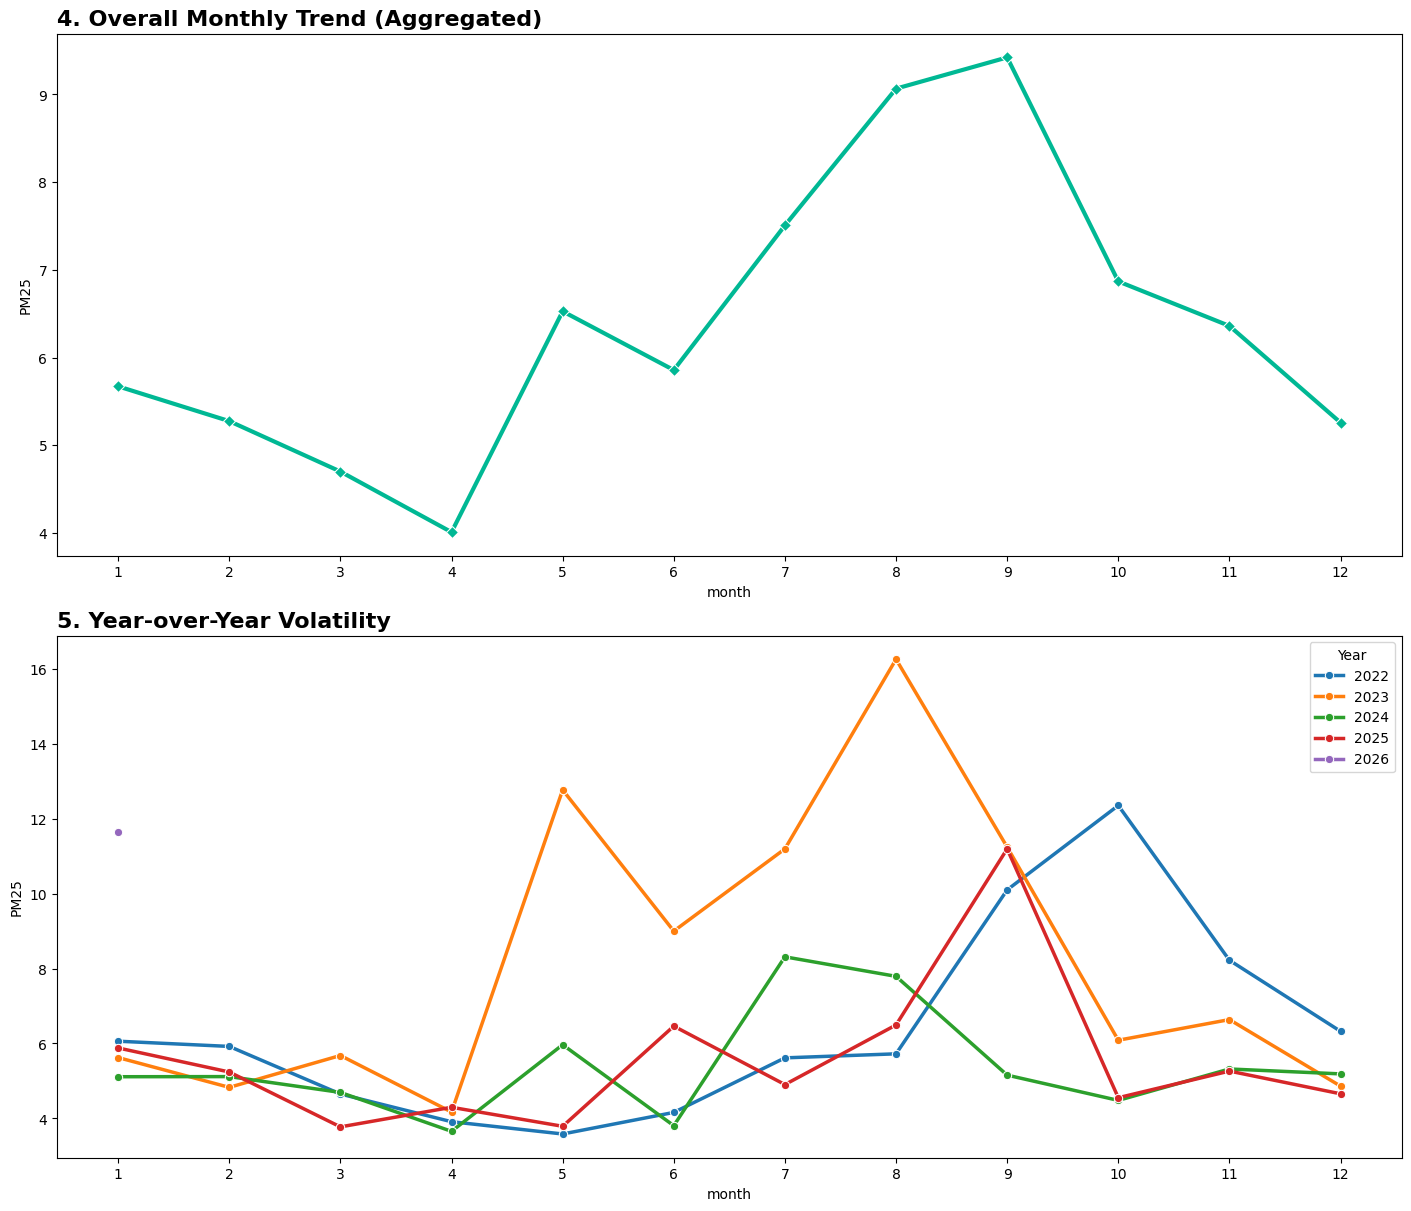

In [55]:
# ---------------------------------------------------------
# ACT 2 Part 1: Monthly & Yearly Patterns
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(2, 1, figsize=(14, 12), constrained_layout=True)

# --- Chart 4: Overall Monthly Trend (Aggregated) ---
monthly_avg = df.groupby('month')[val_col].mean().reset_index()

sns.lineplot(data=monthly_avg, x='month', y=val_col, ax=axes2[0], 
             marker='D', color='#00b894', linewidth=3)

axes2[0].set_title('4. Overall Monthly Trend (Aggregated)', fontsize=16, fontweight='bold', loc='left')
axes2[0].set_xticks(range(1, 13))

# --- Chart 5: Year-over-Year Volatility ---
monthly_yearly_avg = df.groupby(['year', 'month'])[val_col].mean().reset_index()

sns.lineplot(data=monthly_yearly_avg, x='month', y=val_col, hue='year', ax=axes2[1], 
             marker='o', palette='tab10', linewidth=2.5)

axes2[1].set_title('5. Year-over-Year Volatility', fontsize=16, fontweight='bold', loc='left')
axes2[1].set_xticks(range(1, 13))
axes2[1].legend(title='Year', loc='upper right')

plt.show()

### Section 2.1.3 Act 3: Long-term Climate Context
This is the final, most complex chart. It plots the entire timeline but adds background colors representing seasons. This helps visually correlate spikes in data with seasonal events (e.g., Wildfires in Summer, Stagnation in Winter).

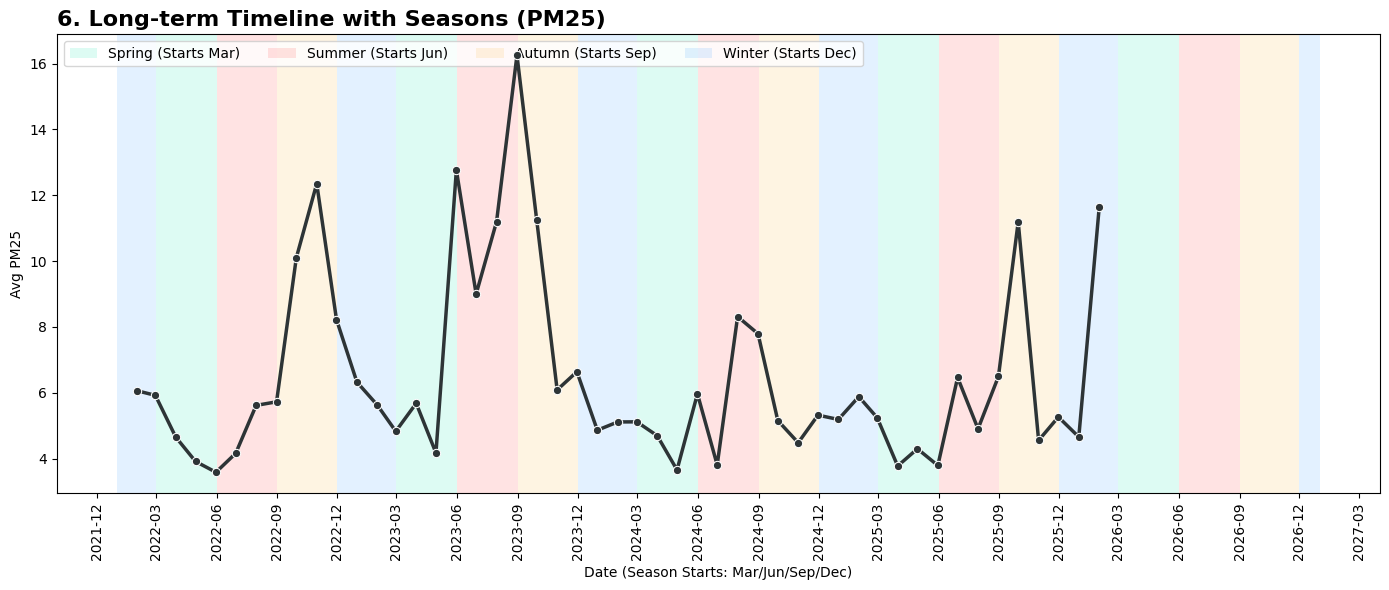

In [56]:
# ---------------------------------------------------------
# ACT 2 Part 2: Long-term Timeline with Seasons
# ---------------------------------------------------------
# Group by Month End ('ME') to create a smooth long-term trend line
long_term_trend = df.groupby(pd.Grouper(key=time_col, freq='ME'))[val_col].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

# Plot the main trend line
sns.lineplot(
    data=long_term_trend, x=time_col, y=val_col,
    ax=ax, marker='o', color='#2d3436', linewidth=2.5, zorder=10
)

ax.set_title(f'6. Long-term Timeline with Seasons ({val_col})', fontsize=16, fontweight='bold', loc='left')
ax.set_xlabel('Date (Season Starts: Mar/Jun/Sep/Dec)')
ax.set_ylabel(f'Avg {val_col}')

# Define seasonal colors (Spring=Green, Summer=Red, Autumn=Yellow, Winter=Blue)
season_colors = {
    'Spring': '#55efc4', 'Summer': '#ff7675', 
    'Autumn': '#fdcb6e', 'Winter': '#74b9ff'
}

# Automatically paint the background for every year in the dataset
start_year = df[time_col].dt.year.min()
end_year = df[time_col].dt.year.max()

for year in range(start_year, end_year + 1):
    # Spring (Mar-May)
    ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-06-01'), color=season_colors['Spring'], alpha=0.2, lw=0)
    # Summer (Jun-Aug)
    ax.axvspan(pd.Timestamp(f'{year}-06-01'), pd.Timestamp(f'{year}-09-01'), color=season_colors['Summer'], alpha=0.2, lw=0)
    # Autumn (Sep-Nov)
    ax.axvspan(pd.Timestamp(f'{year}-09-01'), pd.Timestamp(f'{year}-12-01'), color=season_colors['Autumn'], alpha=0.2, lw=0)
    # Winter (Dec-Feb next year) - Split into two parts to handle year-end
    ax.axvspan(pd.Timestamp(f'{year}-12-01'), pd.Timestamp(f'{year+1}-01-01'), color=season_colors['Winter'], alpha=0.2, lw=0)
    ax.axvspan(pd.Timestamp(f'{year}-01-01'), pd.Timestamp(f'{year}-03-01'), color=season_colors['Winter'], alpha=0.2, lw=0)

# Create a custom legend for the seasonal background colors
legend_seasons = [
    Patch(facecolor=season_colors['Spring'], alpha=0.2, label='Spring (Starts Mar)'),
    Patch(facecolor=season_colors['Summer'], alpha=0.2, label='Summer (Starts Jun)'),
    Patch(facecolor=season_colors['Autumn'], alpha=0.2, label='Autumn (Starts Sep)'),
    Patch(facecolor=season_colors['Winter'], alpha=0.2, label='Winter (Starts Dec)')
]
ax.legend(handles=legend_seasons, loc='upper left', ncol=4, frameon=True)

# Format X-axis to only show the start of seasons (Months 3, 6, 9, 12)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[3, 6, 9, 12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) 
plt.setp(ax.xaxis.get_majorticklabels(), rotation=90)

plt.tight_layout()
plt.show()

## Section 2.2: 2 Dimension Variables
In this section, we focus on the two dimension variable only.

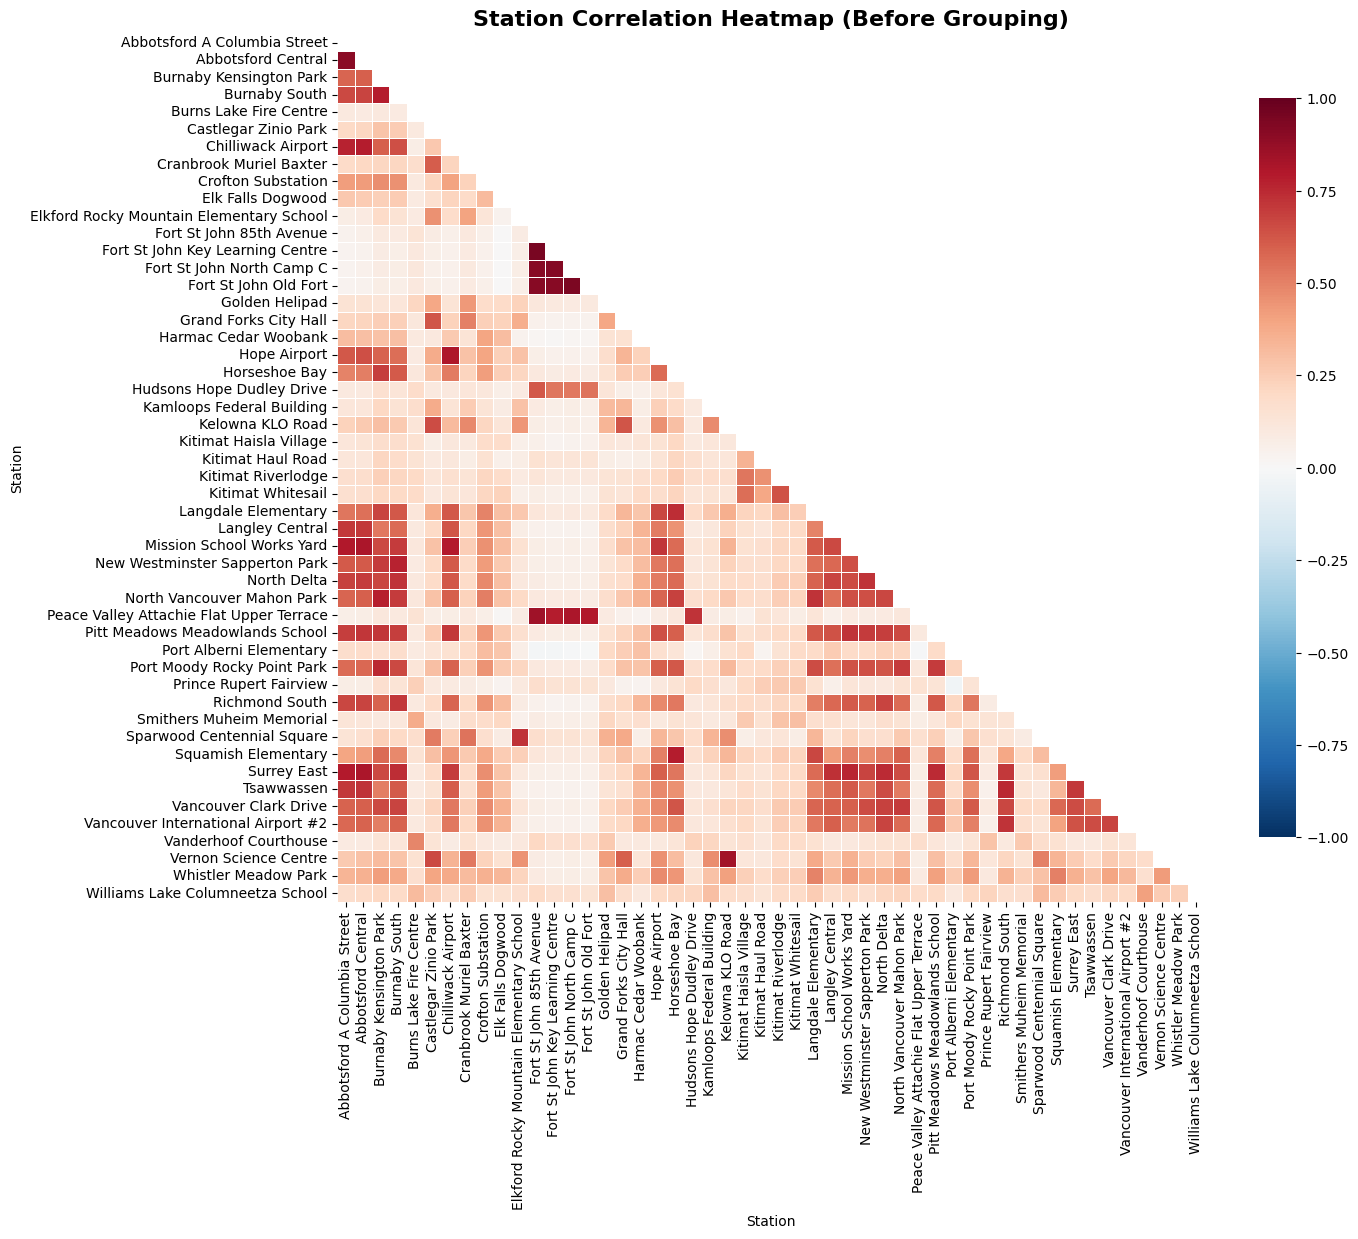

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 假設 full_imputed_data_with_air_zones 已經存在於你的環境中
# full_imputed_data_with_air_zones = ... 

# ---------------------------------------------------------
# 1. Preparation: Pivot & Raw Correlation
# ---------------------------------------------------------
# Create wide-format data where each column is a Station
pivot_df = full_imputed_data.pivot_table(
    index='Datetime', 
    columns='Station', 
    values='PM25'
)

# Calculate standard correlation
corr_before = pivot_df.corr()

# Create mask for lower triangle
mask_before = np.triu(np.ones_like(corr_before, dtype=bool))

# --- Plot 1: Before Grouping ---
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_before, 
    mask=mask_before, 
    cmap='RdBu_r', 
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=.5, 
    cbar_kws={"shrink": .8}
)
plt.title('Station Correlation Heatmap (Before Grouping)', fontsize=16, fontweight='bold')
plt.show()

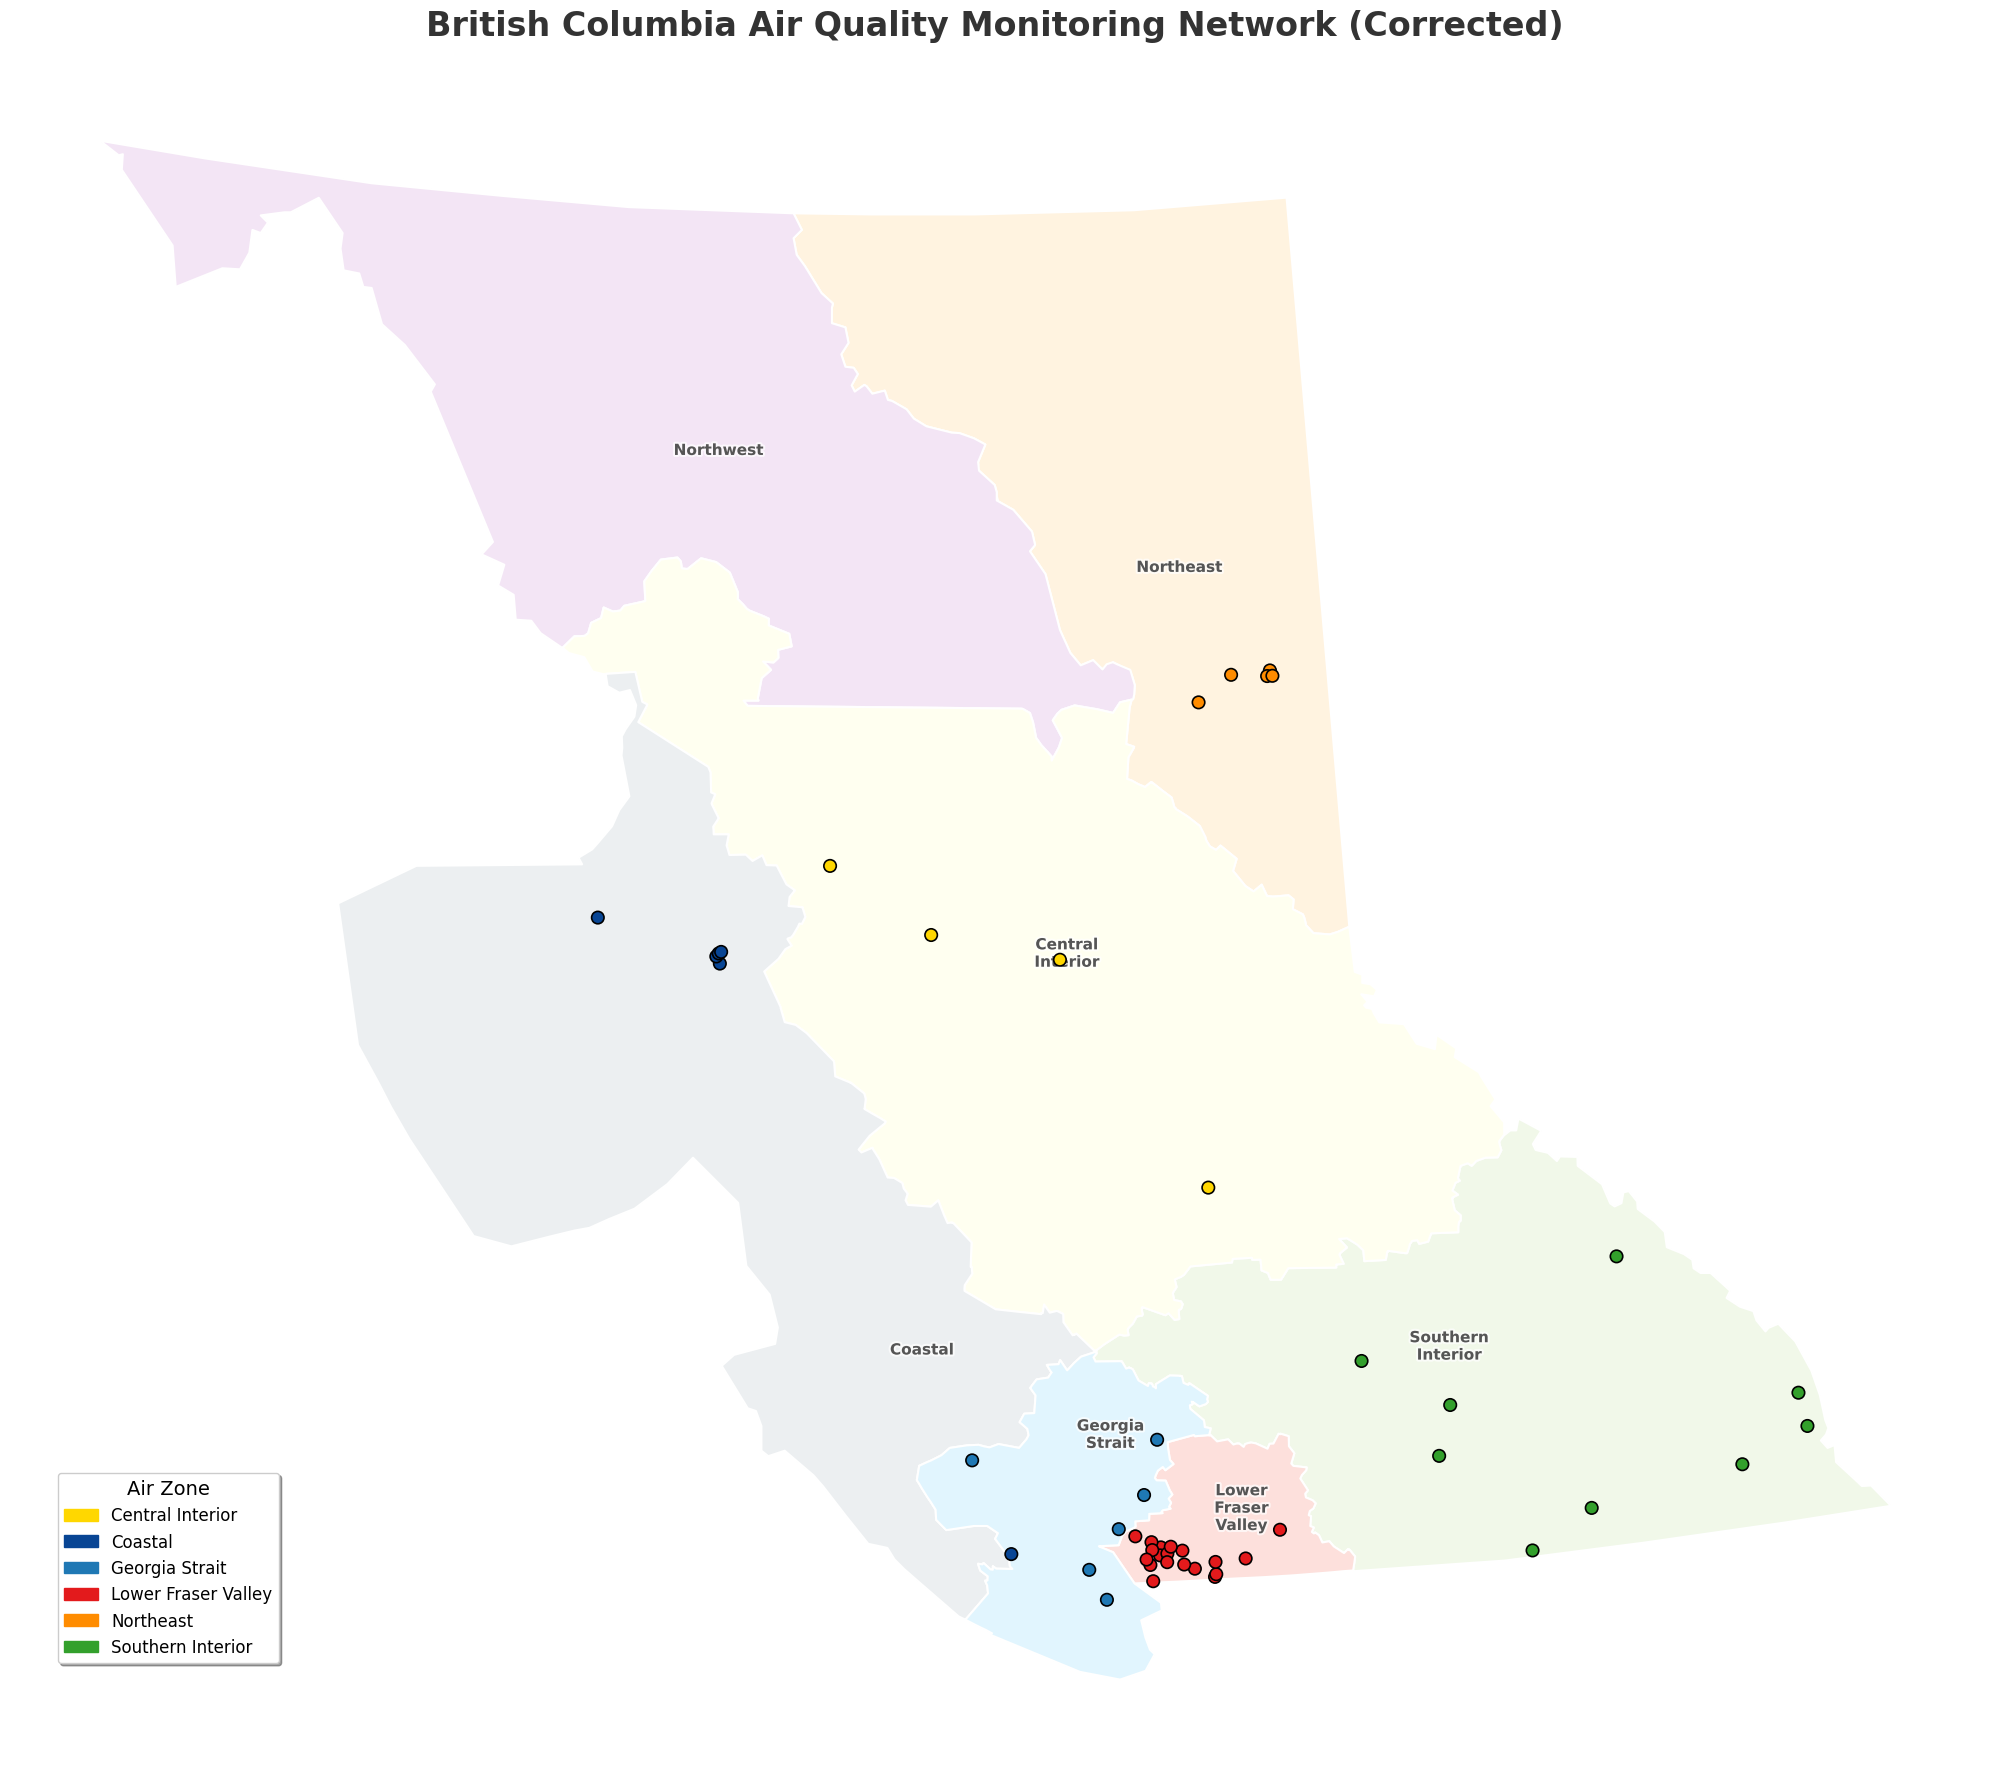

=== 修正後的 12 個孤兒測站歸屬 ===
                 Station Official_Air_Zone
8     Crofton Substation    Georgia Strait
24     Kitimat Haul Road           Coastal
27   Langdale Elementary    Georgia Strait
41   Squamish Elementary    Georgia Strait
48  Whistler Meadow Park    Georgia Strait


In [58]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# ==========================================
# 1. 資料準備
# ==========================================
if 'full_imputed_data' not in locals():
    raise ValueError("請先載入 full_imputed_data")

# 取得測站重心
unique_stations = full_imputed_data.groupby('Station', as_index=False)[['Latitude', 'Longitude']].mean()

# 轉為 GeoDataFrame (BC Albers EPSG:3005)
gdf_stations = gpd.GeoDataFrame(
    unique_stations,
    geometry=gpd.points_from_xy(unique_stations.Longitude, unique_stations.Latitude),
    crs="EPSG:4326"
).to_crs(epsg=3005)

# 讀取地圖
local_filename = "bcairzones.geojson"
gdf_zones = gpd.read_file(local_filename).to_crs(epsg=3005)
zone_col = [c for c in gdf_zones.columns if 'zone' in c.lower() or 'name' in c.lower()][0]
gdf_zones['ZoneName'] = gdf_zones[zone_col]

# ==========================================
# 2. 自動化匹配 (Within)
# ==========================================
join_exact = gpd.sjoin(gdf_stations, gdf_zones, how='left', predicate='within')
mapped_stations = join_exact[['Station', 'ZoneName']].rename(columns={'ZoneName': 'Official_Air_Zone'})

# ==========================================
# 3. 修正字典 (Corrected Dictionary)
# ==========================================
# 這裡修正了 Squamish 和 Whistler 的歸屬，解決視覺衝突
orphan_correction_map = {
    # [Georgia Strait] 溫哥華島東岸
    'Crofton Substation': 'Georgia Strait',
    'Elk Falls Dogwood': 'Georgia Strait',
    'Harmac Cedar Woobank': 'Georgia Strait',
    'Langdale Elementary': 'Georgia Strait', # Sunshine Coast
    'Gibsons Municipal Hall': 'Georgia Strait',
    'Nanaimo Labieux Road': 'Georgia Strait',
    'Nanaimo Departure Bay': 'Georgia Strait',
    'Duncan Cairnsmore': 'Georgia Strait',
    
    # [Coastal] 北部沿海 + 修正後的 Sea-to-Sky 走廊
    'Kitimat Haisla Village': 'Coastal',
    'Kitimat Haul Road': 'Coastal',
    'Kitimat Riverlodge': 'Coastal',
    'Kitimat Whitesail': 'Coastal',
    'Prince Rupert Fairview': 'Coastal',
    'Port Alberni Elementary': 'Coastal',
    
    # 修正重點：將 Squamish 和 Whistler 改為 Coastal 以符合地圖位置
    'Squamish Elementary': 'Georgia Strait',     # 原本是 Lower Fraser Valley -> 改為 Coastal
    'Whistler Meadow Park': 'Georgia Strait'     # 原本是 Lower Fraser Valley -> 改為 Coastal
}

def apply_fixes(row):
    if row['Station'] in orphan_correction_map:
        return orphan_correction_map[row['Station']]
    if pd.notna(row['Official_Air_Zone']):
        return row['Official_Air_Zone']
    return "Unknown"

mapped_stations['Official_Air_Zone'] = mapped_stations.apply(apply_fixes, axis=1)

# 合併回主資料
full_imputed_data_with_air_zones = pd.merge(full_imputed_data, mapped_stations.drop_duplicates(), on='Station', how='left')

# ==========================================
# 4. 繪圖 (Visualization)
# ==========================================
# 重新計算繪圖座標
plot_data = full_imputed_data_with_air_zones.groupby('Station', as_index=False).agg({
    'Latitude': 'mean', 'Longitude': 'mean', 'Official_Air_Zone': 'first'
})
gdf_plot = gpd.GeoDataFrame(plot_data, geometry=gpd.points_from_xy(plot_data.Longitude, plot_data.Latitude), crs="EPSG:4326").to_crs(epsg=3005)

# 定義配色 (背景淡、點位深)
bg_palette = {
    'Northeast': '#FFF3E0', 'Central Interior': '#FFFFF0', 'Southern Interior': '#F1F8E9',
    'Lower Fraser Valley': '#FDE0DC', 'Georgia Strait': '#E1F5FE', 'Coastal': '#ECEFF1', 'Northwest': '#F3E5F5'
}
point_palette = {
    'Northeast': '#FF8C00', 'Central Interior': '#FFD700', 'Southern Interior': '#33A02C',
    'Lower Fraser Valley': '#E31A1C', 'Georgia Strait': '#1F78B4', 'Coastal': '#084594', 'Northwest': '#6A3D9A'
}

fig, ax = plt.subplots(figsize=(20, 18))

# A. 繪製背景與標籤
for zone_name in gdf_zones['ZoneName'].unique():
    zone_geom = gdf_zones[gdf_zones['ZoneName'] == zone_name]
    zone_geom.plot(ax=ax, color=bg_palette.get(zone_name, '#eee'), edgecolor='white', linewidth=1.5)

# B. 加上區域名稱 (Text)
for idx, row in gdf_zones.iterrows():
    pt = row.geometry.representative_point()
    ax.annotate(text=row['ZoneName'].replace(" ", "\n"), xy=(pt.x, pt.y), ha='center', va='center',
                fontsize=11, fontweight='bold', color='#555555',
                path_effects=[pe.withStroke(linewidth=3, foreground="white", alpha=0.7)], zorder=5)

# C. 繪製測站 (Points)
gdf_plot['color'] = gdf_plot['Official_Air_Zone'].map(point_palette)
gdf_plot.plot(ax=ax, color=gdf_plot['color'], marker='o', markersize=80, edgecolor='black', linewidth=1.2, zorder=10)

# D. 裝飾
ax.set_title("British Columbia Air Quality Monitoring Network (Corrected)", fontsize=24, fontweight='bold', pad=20, color='#333333')
ax.set_axis_off()

legend_handles = [mpatches.Patch(color=point_palette[z], label=z) for z in sorted(plot_data['Official_Air_Zone'].unique()) if z in point_palette]
plt.legend(handles=legend_handles, title="Air Zone", title_fontsize=14, fontsize=12, loc='lower left', bbox_to_anchor=(0.02, 0.05), shadow=True)

plt.tight_layout()
plt.show()

# 驗證輸出
print("=== 修正後的 12 個孤兒測站歸屬 ===")
check_list = ['Squamish Elementary', 'Whistler Meadow Park', 'Crofton Substation', 'Langdale Elementary', 'Kitimat Haul Road']
print(mapped_stations[mapped_stations['Station'].isin(check_list)].drop_duplicates())

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# ---------------------------------------------------------
# 1. Setup & Regional Aggregation
# ---------------------------------------------------------
df = full_imputed_data_with_air_zones.copy()

# Configuration
time_col = 'Datetime'       
val_col = 'PM25'            
zone_col = 'Official_Air_Zone'       

# Ensure datetime and sort
df[time_col] = pd.to_datetime(df[time_col])
df.sort_values(by=time_col, inplace=True)

# Generate Time Features
df['hour'] = df[time_col].dt.hour
df['day_of_week'] = df[time_col].dt.day_name()
df['month'] = df[time_col].dt.month
df['year'] = df[time_col].dt.year
df['day_type'] = df[time_col].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Sorting order for the week
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Use a high-contrast palette for clear distinction between zones
distinct_palette = sns.color_palette("bright", n_colors=df[zone_col].nunique())

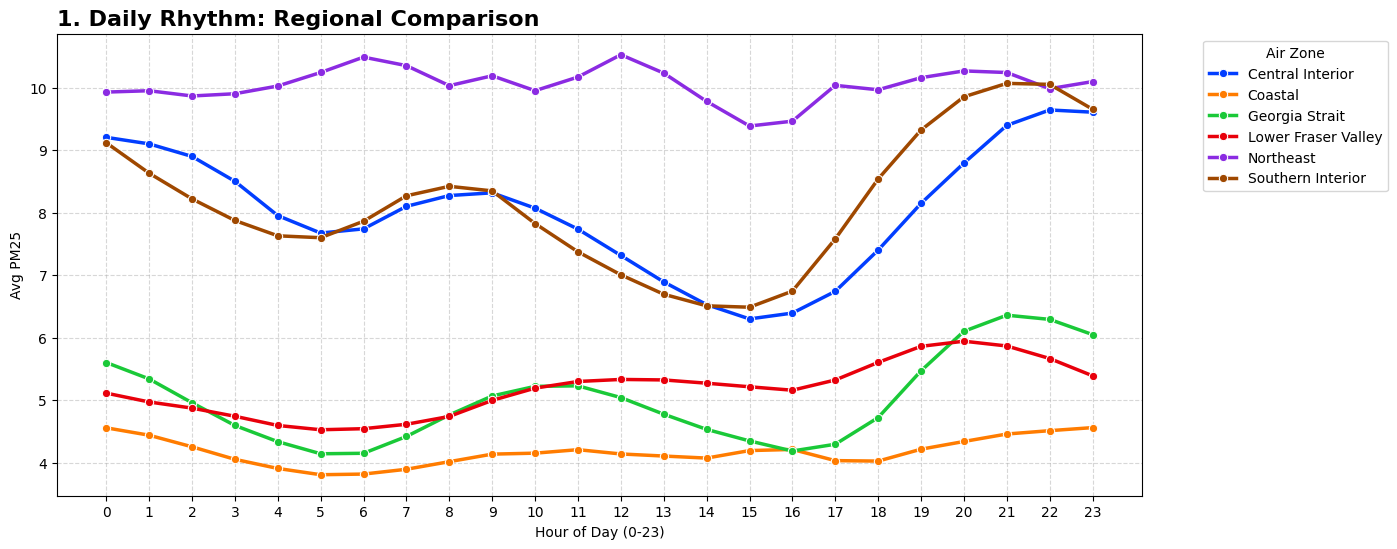

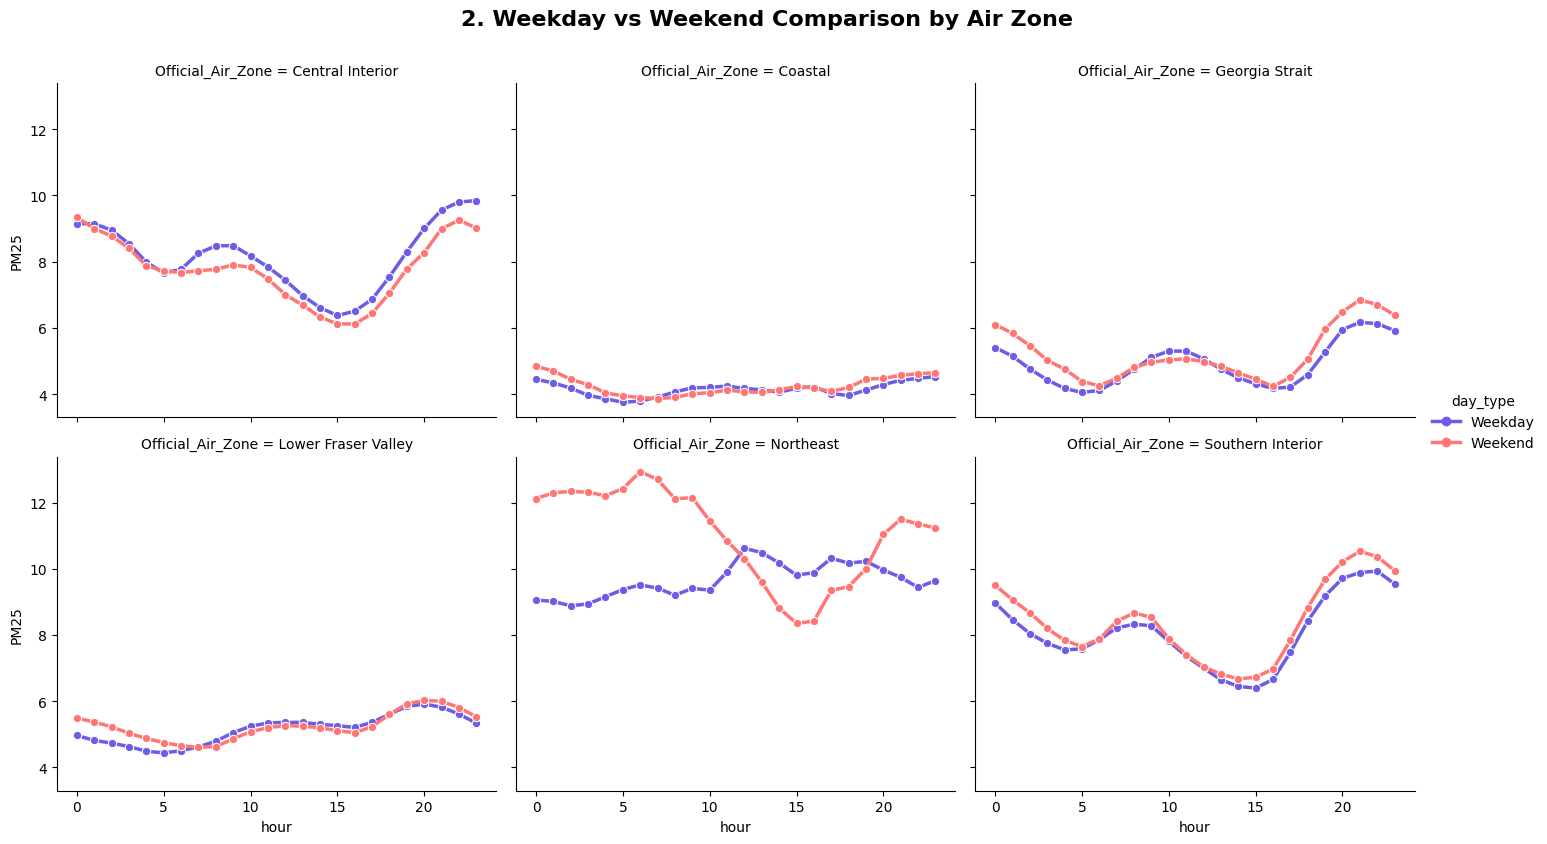

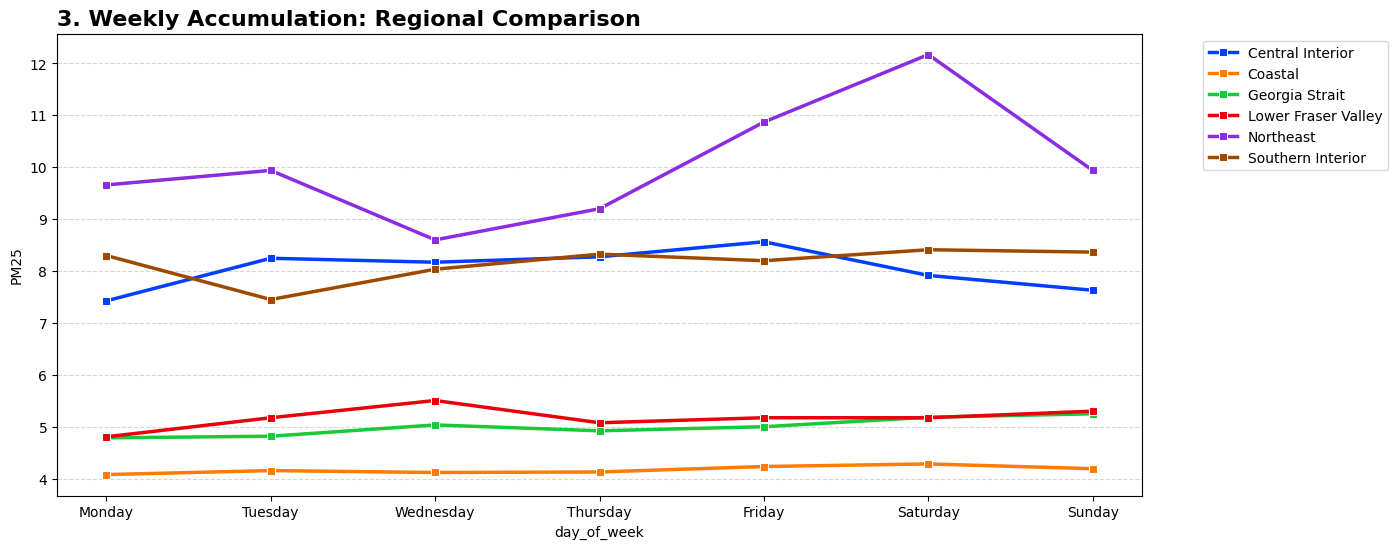

In [60]:
# ---------------------------------------------------------
# ACT 1: Micro-Analysis (Human Fingerprint by Zone)
# ---------------------------------------------------------

# --- Chart 1: Daily Rhythm Comparison ---
daily_zone = df.groupby(['hour', zone_col])[val_col].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_zone, x='hour', y=val_col, hue=zone_col, 
             marker='o', linewidth=2.5, palette=distinct_palette)

plt.title('1. Daily Rhythm: Regional Comparison', fontsize=16, fontweight='bold', loc='left')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel(f'Avg {val_col}')
plt.xticks(range(0, 24))
plt.legend(title='Air Zone', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- Chart 2: Weekday vs. Weekend (Faceted) ---
split_zone = df.groupby(['hour', 'day_type', zone_col])[val_col].mean().reset_index()

g = sns.relplot(
    data=split_zone, x='hour', y=val_col, hue='day_type', col=zone_col,
    kind='line', marker='o', linewidth=2.5,
    palette={'Weekday': '#6c5ce7', 'Weekend': '#ff7675'},
    col_wrap=3, height=4, aspect=1.2
)
g.fig.suptitle('2. Weekday vs Weekend Comparison by Air Zone', fontsize=16, fontweight='bold', y=1.05)
plt.show()

# --- Chart 3: Weekly Accumulation Comparison ---
weekly_zone = df.groupby(['day_of_week', zone_col])[val_col].mean().reset_index()
weekly_zone['day_of_week'] = pd.Categorical(weekly_zone['day_of_week'], categories=week_order, ordered=True)

plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_zone, x='day_of_week', y=val_col, hue=zone_col, 
             marker='s', linewidth=2.5, palette=distinct_palette)

plt.title('3. Weekly Accumulation: Regional Comparison', fontsize=16, fontweight='bold', loc='left')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

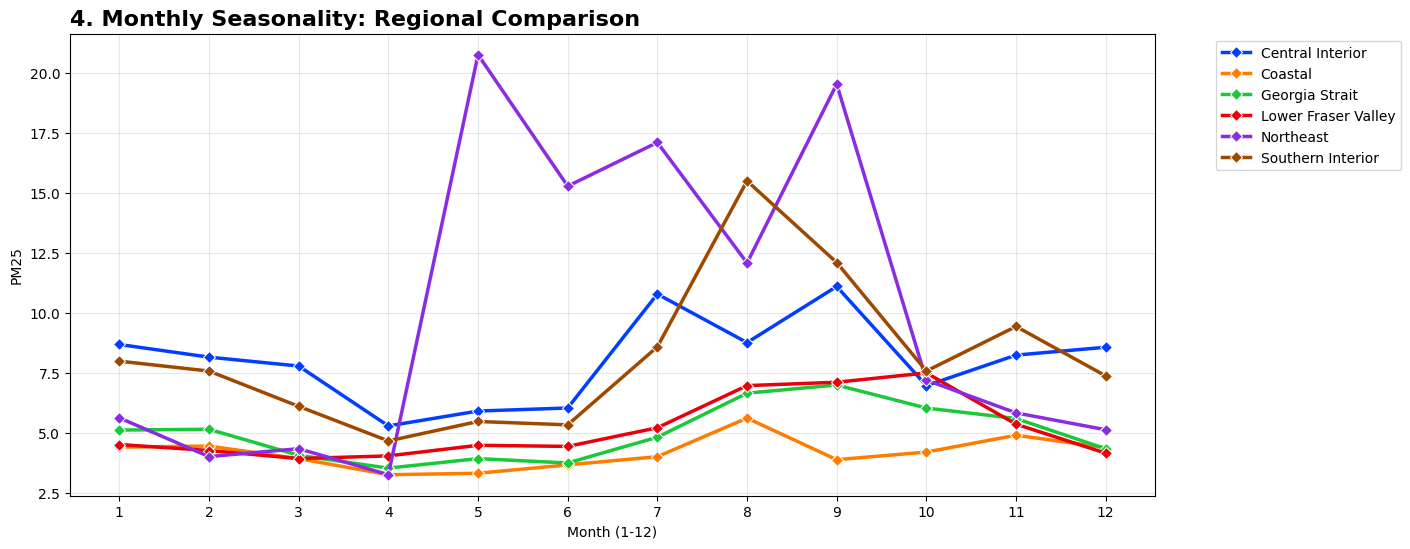

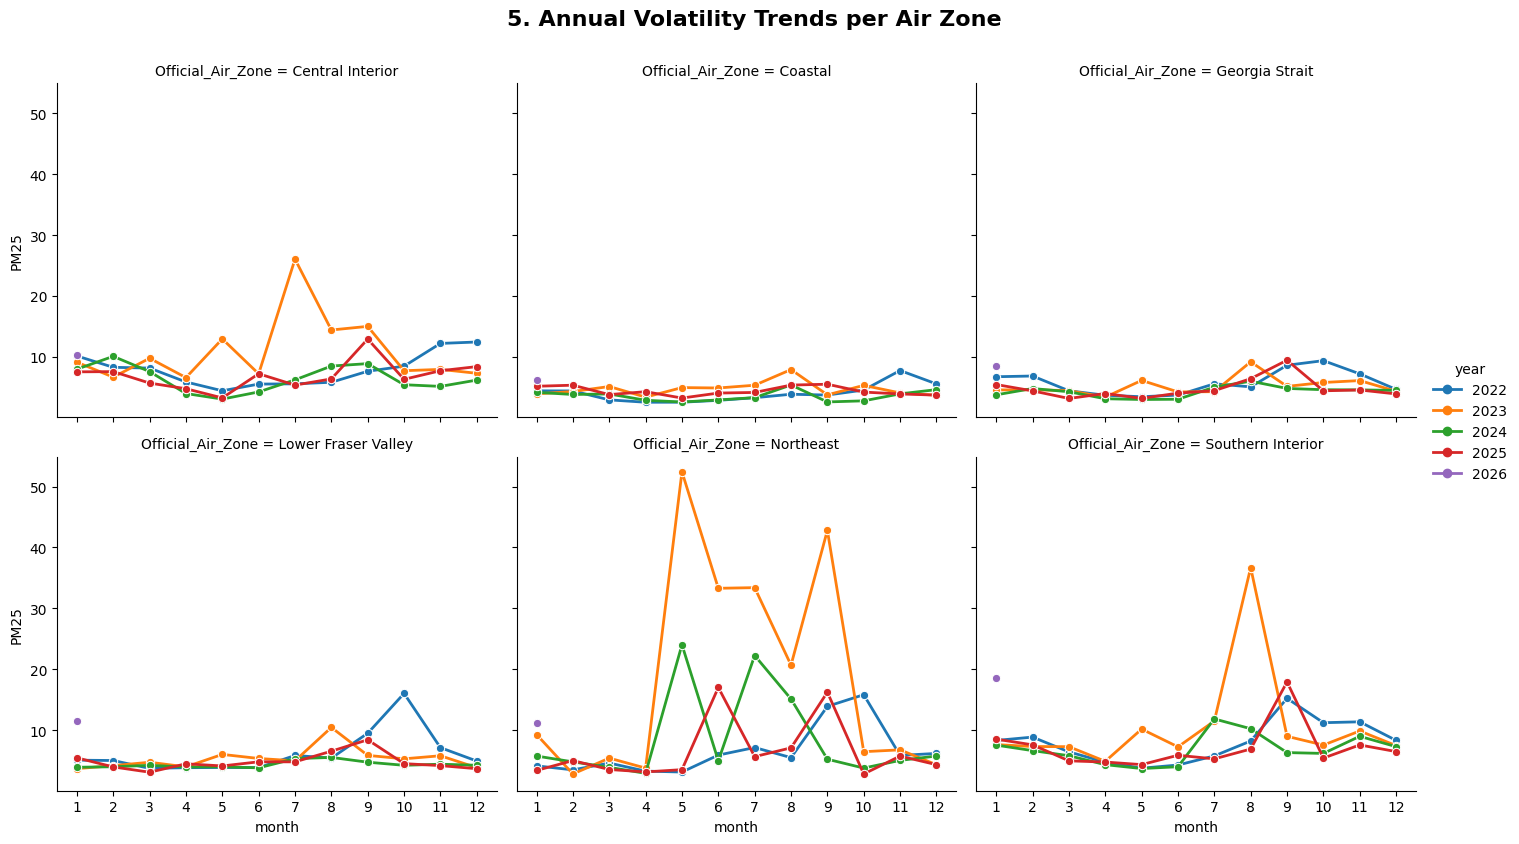

In [61]:
# ---------------------------------------------------------
# ACT 2: Macro-Analysis (Seasonal Trends by Zone)
# ---------------------------------------------------------

# --- Chart 4: Overall Monthly Seasonality ---
monthly_zone = df.groupby(['month', zone_col])[val_col].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_zone, x='month', y=val_col, hue=zone_col, 
             marker='D', linewidth=2.5, palette=distinct_palette)

plt.title('4. Monthly Seasonality: Regional Comparison', fontsize=16, fontweight='bold', loc='left')
plt.xticks(range(1, 13))
plt.xlabel('Month (1-12)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# --- Chart 5: Year-over-Year Volatility (Faceted) ---
monthly_yearly_zone = df.groupby(['year', 'month', zone_col])[val_col].mean().reset_index()

g = sns.relplot(
    data=monthly_yearly_zone, x='month', y=val_col, hue='year', col=zone_col,
    kind='line', marker='o', linewidth=2, palette='tab10',
    col_wrap=3, height=4, aspect=1.2
)
g.fig.suptitle('5. Annual Volatility Trends per Air Zone', fontsize=16, fontweight='bold', y=1.05)
g.set(xticks=range(1, 13))
plt.show()

## Section 2.3: 3 Dimension Variables
In this section, we focus on the two dimension variable only.

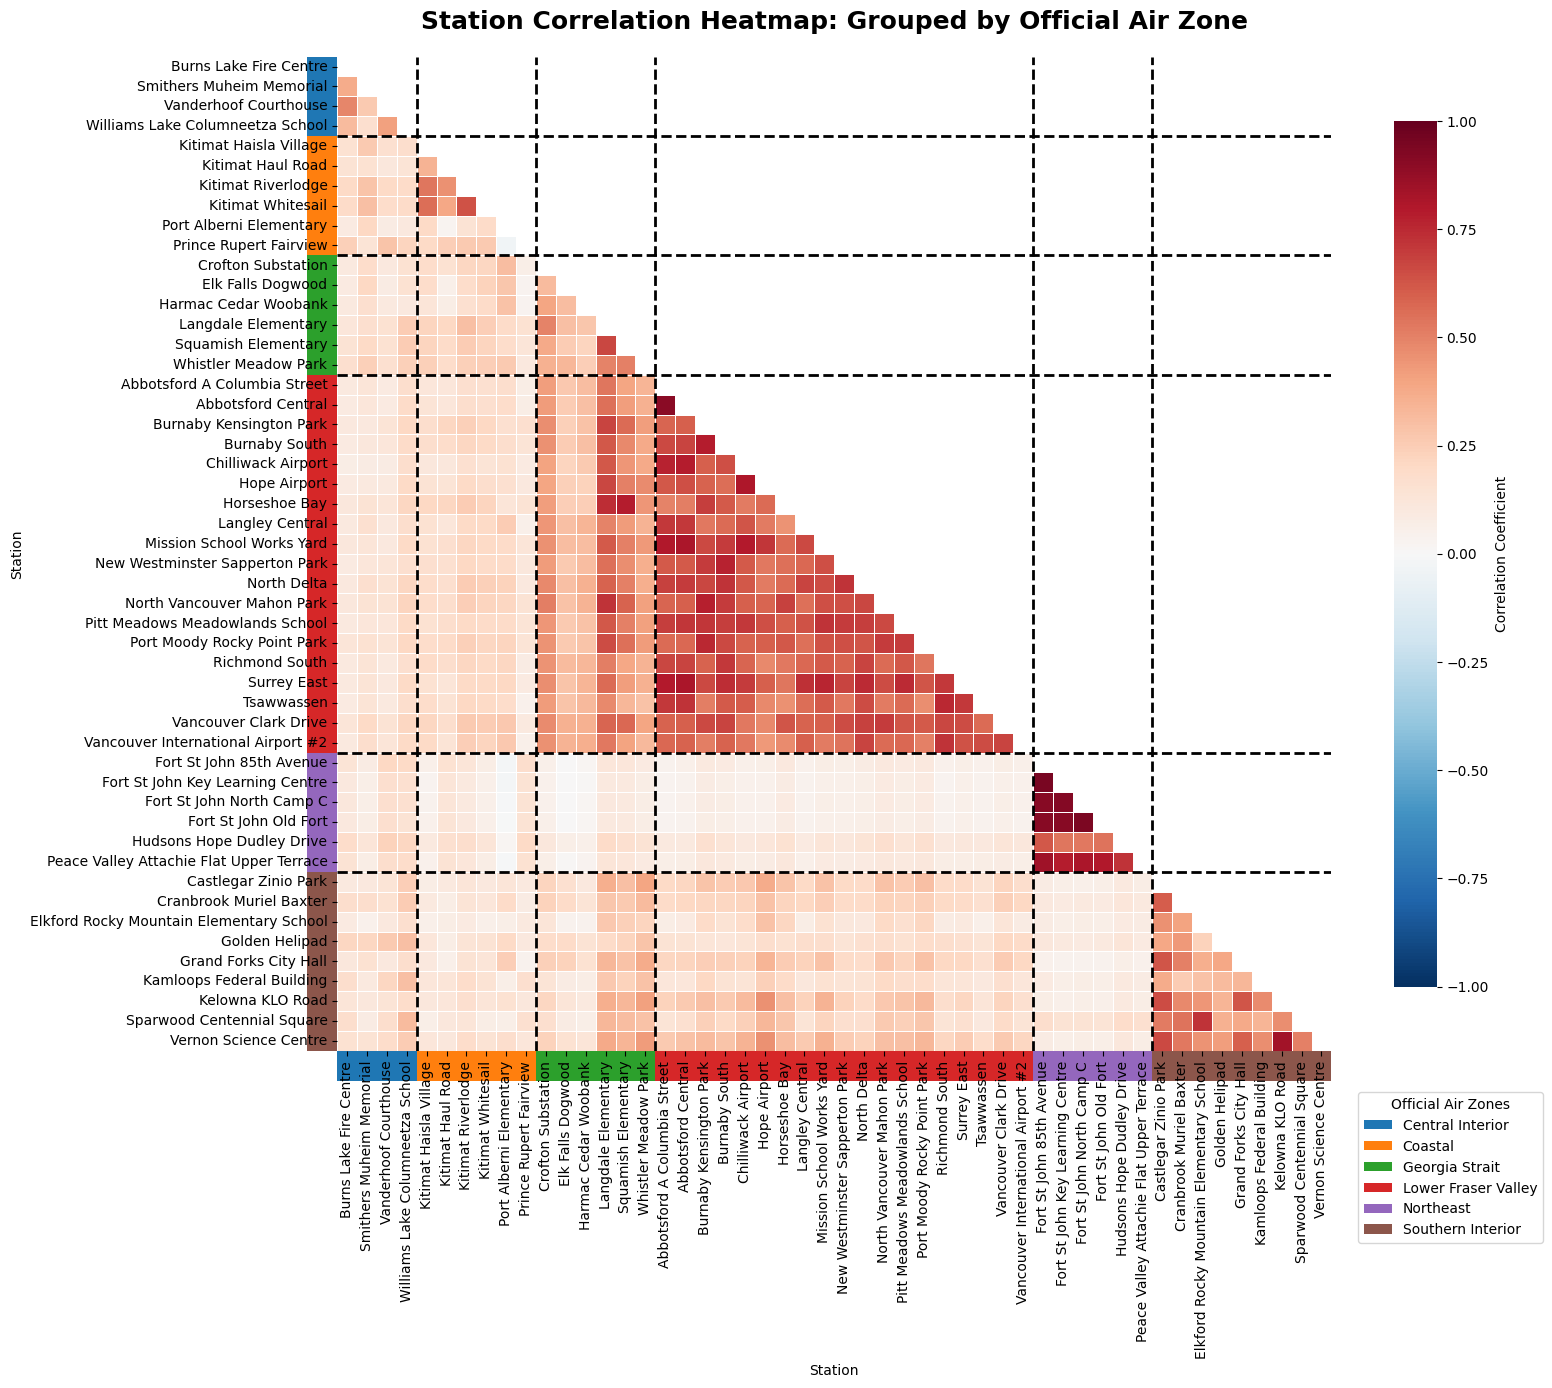

In [62]:
# ---------------------------------------------------------
# 2. Grouped Correlation (Sorted by Official_Air_Zone)
# ---------------------------------------------------------

# Create a unique mapping of Station to its Official_Air_Zone
zone_info = full_imputed_data_with_air_zones[['Station', 'Official_Air_Zone']].drop_duplicates()

# !!! 修改重點：確保排序邏輯 !!!
# 1. 先根據 Air Zone 排序 (讓相同區域聚在一起)
# 2. 再根據 Station 排序 (讓同一區域內的測站按字母排列，視覺更整齊)
zone_info = zone_info.sort_values(by=['Official_Air_Zone', 'Station'])

# 取得排序後的測站列表
sorted_stations = zone_info['Station'].tolist()

# 根據新的順序重新排列 Correlation Matrix
corr_after = corr_before.loc[sorted_stations, sorted_stations]

# 重新製作 Mask (因為矩陣順序變了，Mask 也要重做)
mask_after = np.triu(np.ones_like(corr_after, dtype=bool))

# 設定顏色對應
zones = zone_info['Official_Air_Zone'].unique()
# 使用 tab10 或 bright 色盤確保顏色區別明顯
zone_colors = dict(zip(zones, sns.color_palette("tab10", len(zones))))

# ... (前面的資料準備程式碼保持不變) ...

# --- Plot 2: After Grouping ---
fig, ax = plt.subplots(figsize=(16, 14))

# 繪製 Heatmap
sns.heatmap(
    corr_after, 
    mask=mask_after, 
    cmap='RdBu_r', 
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=.5, 
    cbar_kws={"shrink": .8, "label": "Correlation Coefficient"},
    ax=ax
)

# --- Add Visual Markers & Grid Lines ---
# 找出 Air Zone 切換的位置索引
zone_values = zone_info['Official_Air_Zone'].values
change_points = np.where(zone_values[:-1] != zone_values[1:])[0] + 1

# 畫出分隔線
for cp in change_points:
    ax.hlines(cp, *ax.get_xlim(), color='black', linewidth=2, linestyle='--')
    ax.vlines(cp, *ax.get_ylim(), color='black', linewidth=2, linestyle='--')

# 添加顏色標籤條 (Color Strips)
for i, station in enumerate(sorted_stations):
    zone = zone_info[zone_info['Station'] == station]['Official_Air_Zone'].values[0]
    color = zone_colors[zone]
    
    # 左側 Y 軸色條
    rect_y = plt.Rectangle((-1.5, i), 1.5, 1, facecolor=color, clip_on=False, transform=ax.transData)
    ax.add_patch(rect_y)
    
    # 底部 X 軸色條
    rect_x = plt.Rectangle((i, len(sorted_stations)), 1, 1.5, facecolor=color, clip_on=False, transform=ax.transData)
    ax.add_patch(rect_x)

# 調整 Legend (關鍵修改)
legend_elements = [Patch(facecolor=c, label=z) for z, c in zone_colors.items()]

# 修改說明：
# 1. loc='lower left': 將 Legend 的定位點改為「左下角」
# 2. bbox_to_anchor=(1.02, 0): 將 Legend 放在軸外側的底部 (y=0)
# 這樣它就會避開上方的 Colorbar
ax.legend(
    handles=legend_elements, 
    title='Official Air Zones', 
    bbox_to_anchor=(1.02, -0.2),  # 改為 0，代表底部
    loc='lower left',          # 改為 lower left，讓它從底部向上長
    frameon=True
)

plt.title('Station Correlation Heatmap: Grouped by Official Air Zone', 
          fontsize=18, fontweight='bold', pad=20)

# 調整 Layout 確保 Legend 不被切掉
plt.tight_layout()
plt.show()

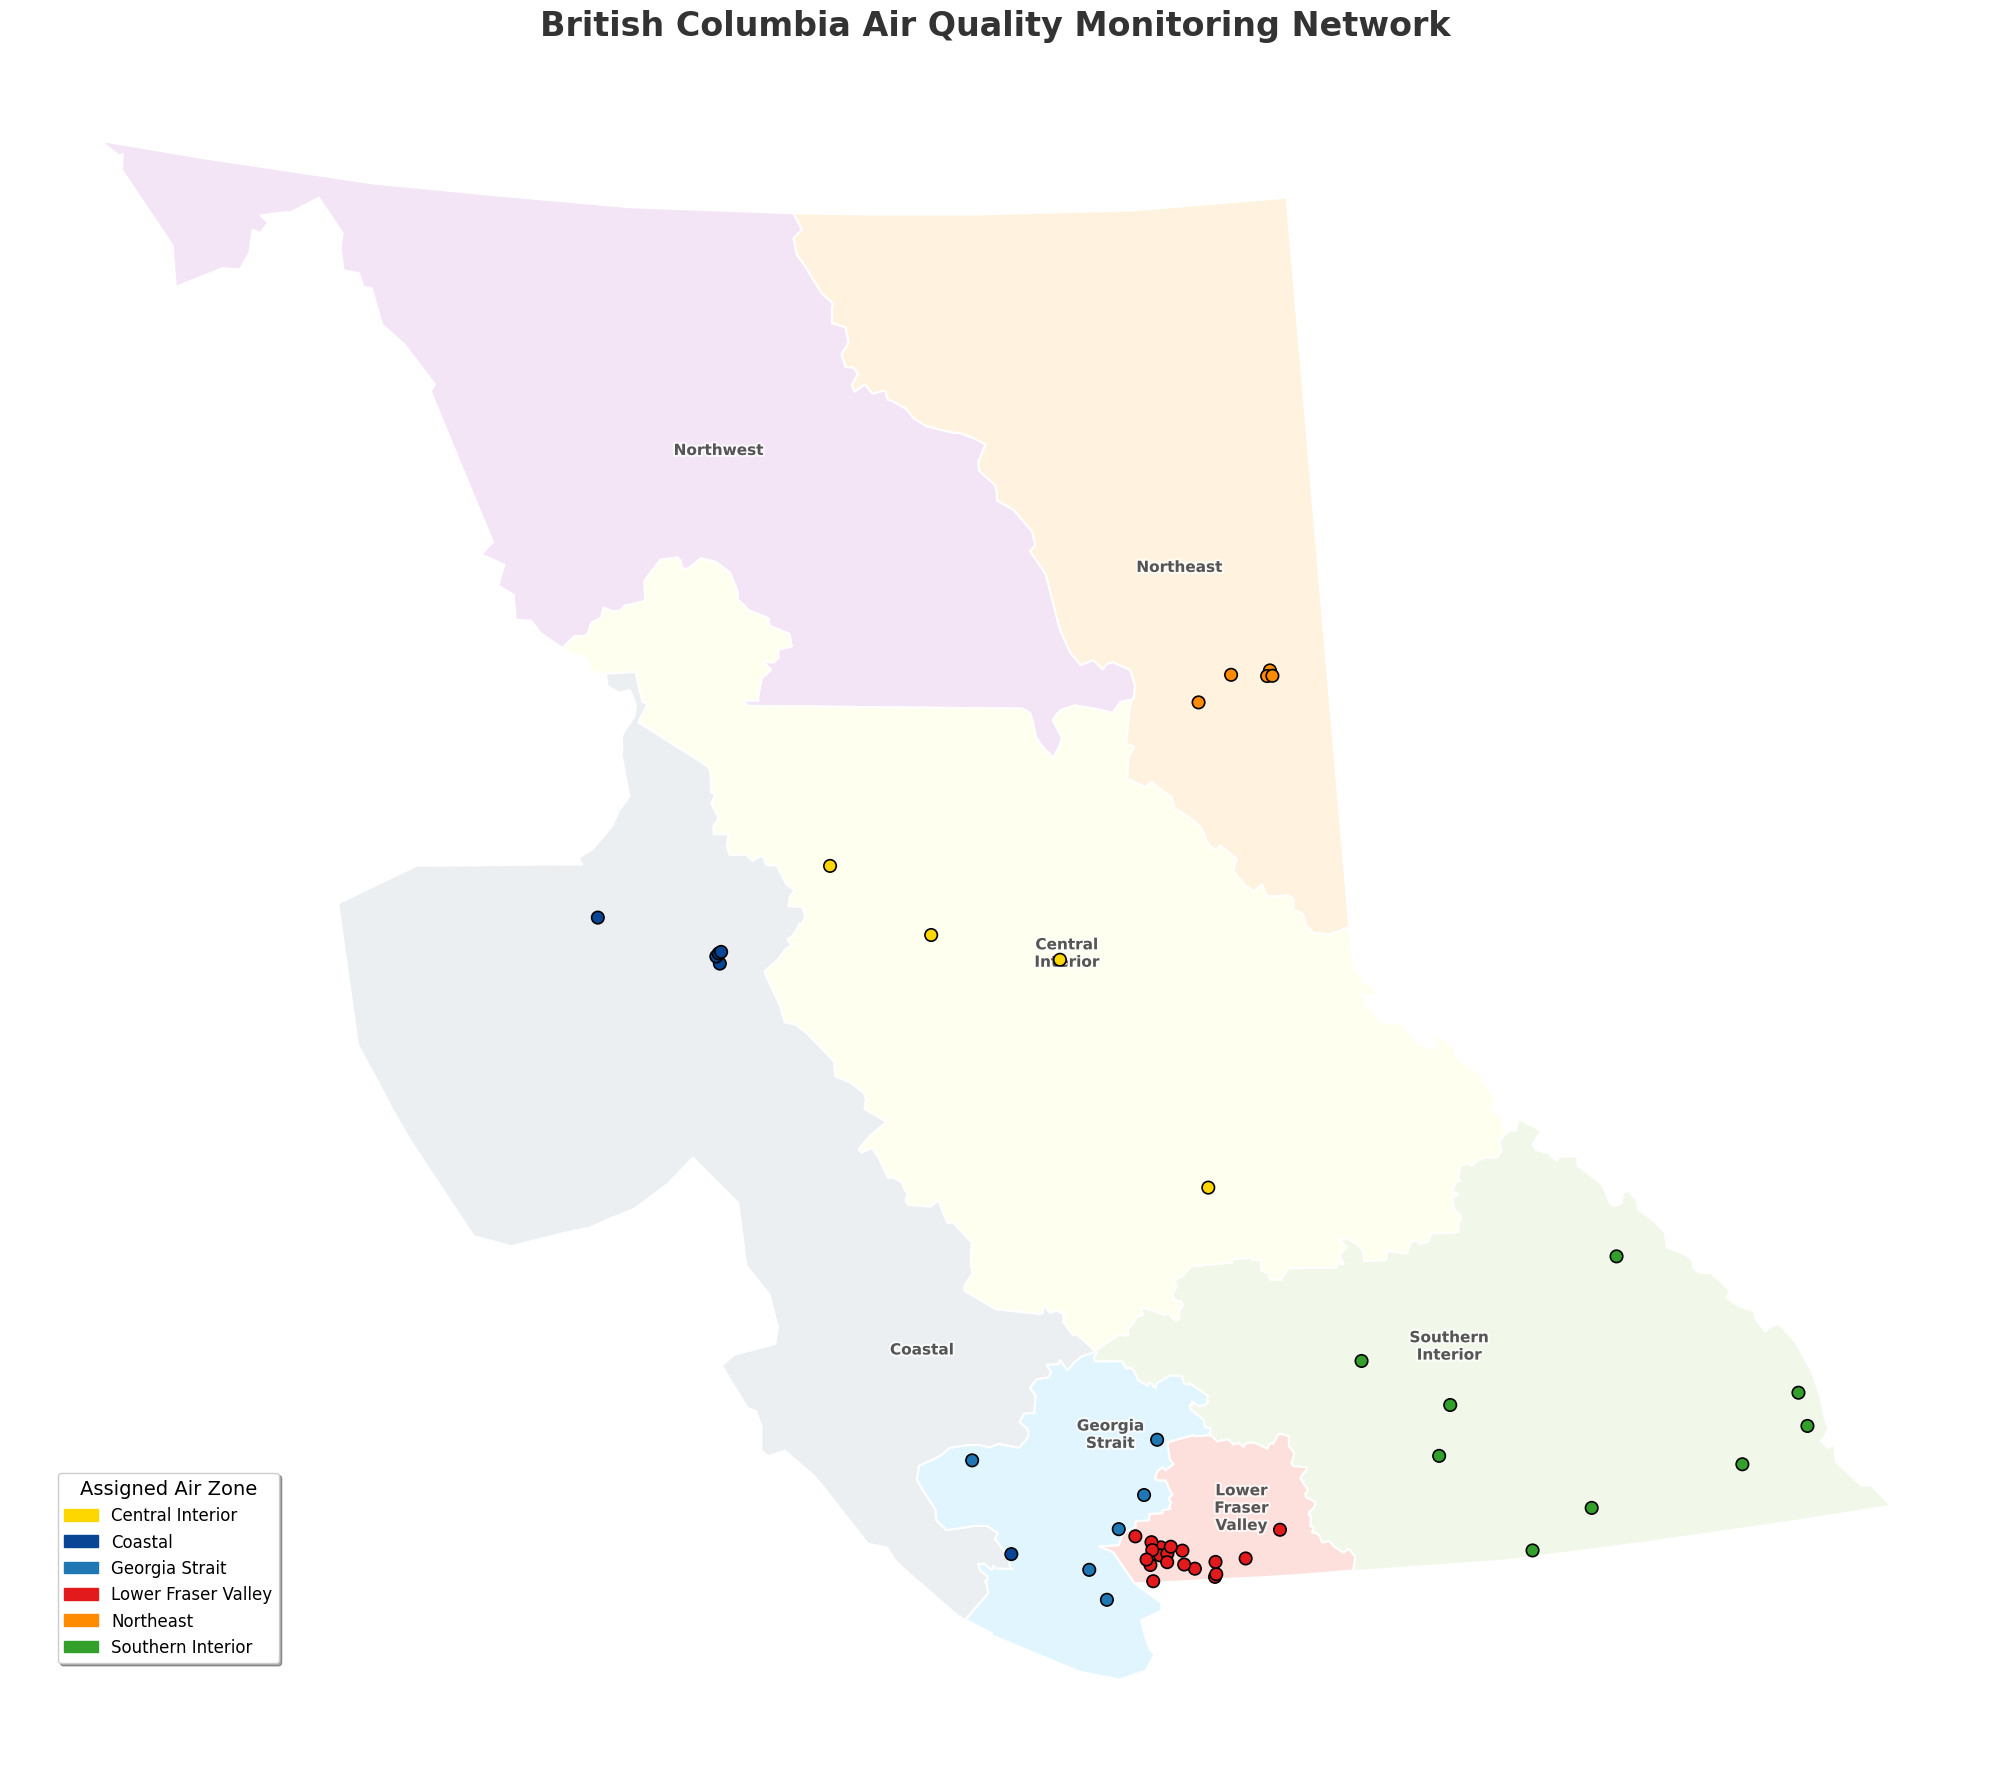

In [63]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# ==========================================
# 1. 資料準備
# ==========================================
if 'full_imputed_data_with_air_zones' not in locals():
    raise ValueError("請先執行修復程式碼，確保 full_imputed_data_with_air_zones 存在。")

# 取得測站座標 (重心)
plot_data = full_imputed_data_with_air_zones.groupby('Station', as_index=False).agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'Official_Air_Zone': 'first'
})

# 轉為 GeoDataFrame (BC Albers EPSG:3005)
gdf_stations = gpd.GeoDataFrame(
    plot_data,
    geometry=gpd.points_from_xy(plot_data.Longitude, plot_data.Latitude),
    crs="EPSG:4326"
).to_crs(epsg=3005)

# 讀取地圖檔
local_filename = "bcairzones.geojson"
gdf_zones = gpd.read_file(local_filename).to_crs(epsg=3005)
zone_col = [c for c in gdf_zones.columns if 'zone' in c.lower() or 'name' in c.lower()][0]
gdf_zones['ZoneName'] = gdf_zones[zone_col]

# ==========================================
# 2. 定義配色 (背景淡、點位深)
# ==========================================
# 背景色 (淡雅)
bg_palette = {
    'Northeast': '#FFF3E0', 'Central Interior': '#FFFFF0', 'Southern Interior': '#F1F8E9',
    'Lower Fraser Valley': '#FDE0DC', 'Georgia Strait': '#E1F5FE', 'Coastal': '#ECEFF1', 'Northwest': '#F3E5F5'
}

# 點位色 (鮮豔)
point_palette = {
    'Northeast': '#FF8C00', 'Central Interior': '#FFD700', 'Southern Interior': '#33A02C',
    'Lower Fraser Valley': '#E31A1C', 'Georgia Strait': '#1F78B4', 'Coastal': '#084594', 'Northwest': '#6A3D9A'
}

# ==========================================
# 3. 繪圖 (Visualization)
# ==========================================
fig, ax = plt.subplots(figsize=(20, 18))

# --- Layer 1: 區域背景 (Polygons) ---
unique_zones = gdf_zones['ZoneName'].unique()
for zone_name in unique_zones:
    zone_geom = gdf_zones[gdf_zones['ZoneName'] == zone_name]
    bg_color = bg_palette.get(zone_name, '#F5F5F5')
    
    zone_geom.plot(
        ax=ax,
        color=bg_color,
        edgecolor='white',
        linewidth=1.5,
        alpha=1.0
    )

# --- Layer 2: 區域文字標籤 (Zone Labels) ---
# 這是您要求的新功能：在地圖上標示名字
for idx, row in gdf_zones.iterrows():
    # 使用 representative_point() 確保文字落在多邊形"內部" (比 centroid 更安全)
    # 特別是對於形狀彎曲的 Coastal 區域很重要
    pt = row.geometry.representative_point()
    
    # 格式化文字 (換行以節省寬度)
    label_text = row['ZoneName'].replace(" ", "\n")
    
    ax.annotate(
        text=label_text,
        xy=(pt.x, pt.y),
        ha='center', va='center',
        fontsize=11,               # 字體大小
        fontweight='bold',         # 粗體
        color='#555555',           # 深灰色 (不搶測站的風頭)
        path_effects=[pe.withStroke(linewidth=3, foreground="white", alpha=0.7)], # 白色光暈，讓字在任何背景都清楚
        zorder=5                   # 放在背景之上，測站之下
    )

# --- Layer 3: 彩色測站點位 (Station Points) ---
# 根據 Air Zone 上色
gdf_stations['color'] = gdf_stations['Official_Air_Zone'].map(point_palette)

gdf_stations.plot(
    ax=ax,
    color=gdf_stations['color'],
    marker='o',
    markersize=80,
    edgecolor='black',  # 黑邊框
    linewidth=1.2,
    zorder=10           # 最上層
)

# ==========================================
# 4. 裝飾
# ==========================================
ax.set_title("British Columbia Air Quality Monitoring Network", 
             fontsize=24, fontweight='bold', pad=20, color='#333333')
ax.set_axis_off()

# 圖例 (Legend)
legend_handles = []
# 只顯示資料中有的區域
existing_zones = sorted(plot_data['Official_Air_Zone'].unique())

for zone in existing_zones:
    if zone in point_palette:
        patch = mpatches.Patch(color=point_palette[zone], label=zone)
        legend_handles.append(patch)

plt.legend(
    handles=legend_handles, 
    title="Assigned Air Zone",
    title_fontsize=14,
    fontsize=12,
    loc='lower left',
    bbox_to_anchor=(0.02, 0.05),
    frameon=True,
    shadow=True
)

plt.tight_layout()
plt.show()

In [64]:
full_imputed_data_with_air_zones["Official_Air_Zone"].value_counts()

Official_Air_Zone
Lower Fraser Valley    666216
Southern Interior      315576
Northeast              210384
Georgia Strait         210384
Coastal                210384
Central Interior       140256
Name: count, dtype: int64

# Section 3: Feature Engineering

# Section 4: Modeling

In [65]:
full_imputed_data_with_air_zones.head()

,Datetime,Station,PM25,Latitude,Longitude,Official_Air_Zone
0,2022-01-01 01:00:00,Abbotsford A Columbia Street,2.840752,49.021500,-122.326500,Lower Fraser Valley
1,2022-01-01 01:00:00,Abbotsford Central,14.556050,49.042600,-122.309800,Lower Fraser Valley
2,2022-01-01 01:00:00,Burnaby Kensington Park,11.800620,49.279200,-122.970700,Lower Fraser Valley
3,2022-01-01 01:00:00,Burnaby South,3.421575,49.215200,-122.985700,Lower Fraser Valley
4,2022-01-01 01:00:00,Burns Lake Fire Centre,3.517412,54.230731,-125.764354,Central Interior


In [66]:
full_imputed_data_with_air_zones.columns

Index(['Datetime', 'Station', 'PM25', 'Latitude', 'Longitude',
       'Official_Air_Zone'],
      dtype='object')

In [67]:
full_imputed_data_with_air_zones

,Datetime,Station,PM25,Latitude,Longitude,Official_Air_Zone
0,2022-01-01 01:00:00,Abbotsford A Columbia Street,2.840752,49.021500,-122.326500,Lower Fraser Valley
1,2022-01-01 01:00:00,Abbotsford Central,14.556050,49.042600,-122.309800,Lower Fraser Valley
2,2022-01-01 01:00:00,Burnaby Kensington Park,11.800620,49.279200,-122.970700,Lower Fraser Valley
3,2022-01-01 01:00:00,Burnaby South,3.421575,49.215200,-122.985700,Lower Fraser Valley
4,2022-01-01 01:00:00,Burns Lake Fire Centre,3.517412,54.230731,-125.764354,Central Interior
...,...,...,...,...,...,...
1753195,2026-01-01 00:00:00,Vancouver International Airport #2,5.778112,49.186300,-123.152400,Lower Fraser Valley
1753196,2026-01-01 00:00:00,Vanderhoof Courthouse,15.000000,54.016300,-124.006100,Central Interior
1753197,2026-01-01 00:00:00,Vernon Science Centre,19.825056,50.260617,-119.270723,Southern Interior
1753198,2026-01-01 00:00:00,Whistler Meadow Park,3.351097,50.144285,-122.960402,Georgia Strait


>>> Preparing Data for the Model...
Available Zones: ['Central Interior', 'Coastal', 'Georgia Strait', 'Lower Fraser Valley', 'Northeast', 'Southern Interior']
   FINAL VERIFICATION: Signals + Interaction (lam=0.2454)
   Target: Central Interior

>>> Training Final Model with Signals & Interactions...
Test RMSE (2025) with Signals: 1.8162


C:\Users\User\AppData\Local\Temp\ipykernel_52204\227740616.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='residuals', data=test_data, ax=ax2, palette="coolwarm", showfliers=False)
C:\Users\User\AppData\Local\Temp\ipykernel_52204\227740616.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='residuals', data=test_data, ax=ax3, palette="Oranges", showfliers=False)
C:\Users\User\AppData\Local\Temp\ipykernel_52204\227740616.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weekday', y='residuals', data=t

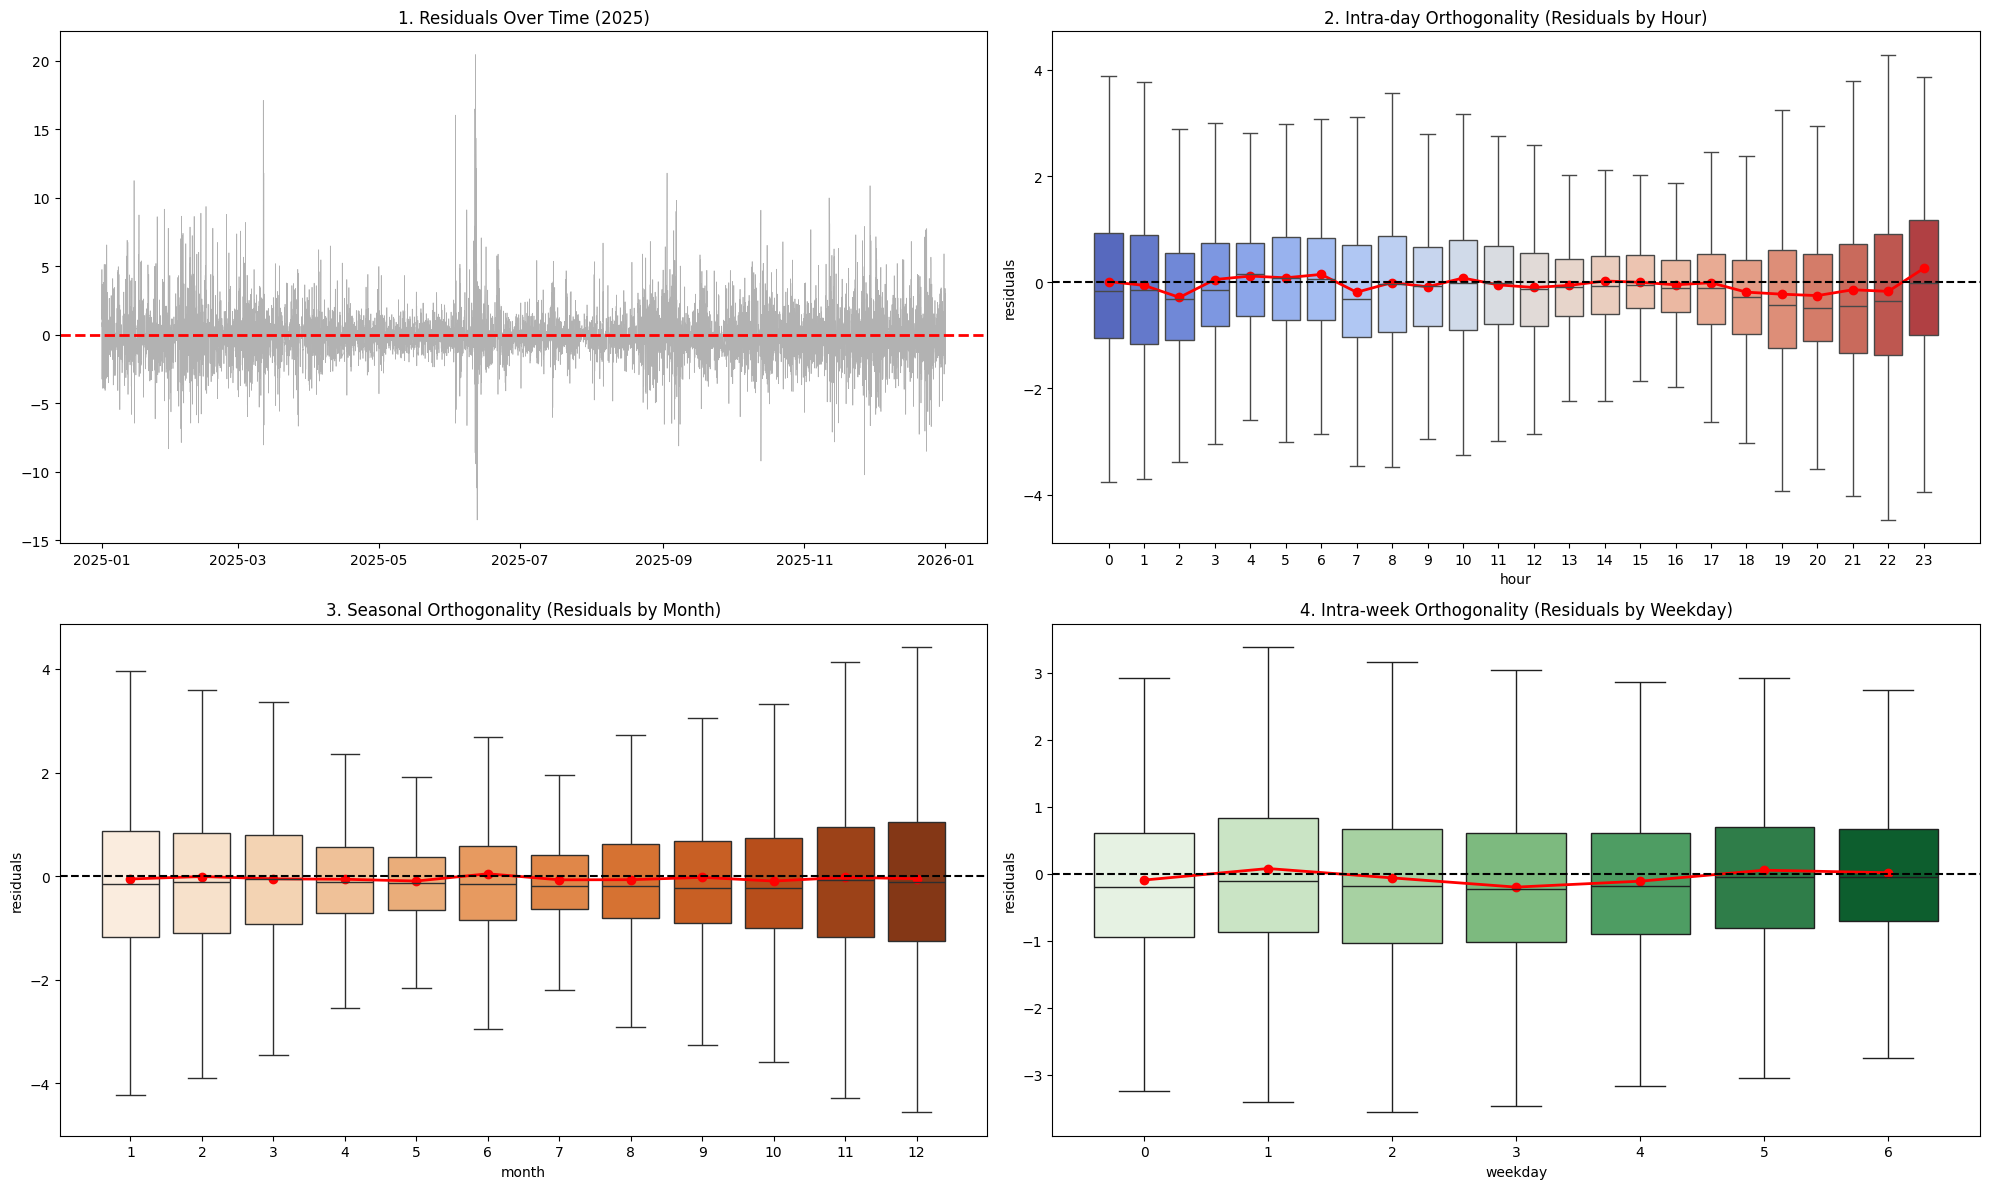


>>> STATISTICAL ORTHOGONALITY TESTS (ANOVA) <<<
  - Residuals vs Hour      : F-Stat = 1.9955 | P-Value = 3.1387e-03
  - Residuals vs Month     : F-Stat = 0.3375 | P-Value = 9.7755e-01
  - Residuals vs Weekday   : F-Stat = 3.7349 | P-Value = 1.0306e-03


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pygam import LinearGAM, s, f, te
from scipy import stats
from sklearn.metrics import mean_squared_error

# 假設你的原始數據框叫做 full_imputed_data_with_air_zones
# 為了方便，我們先複製一份
raw_df = full_imputed_data_with_air_zones.copy()

# ==========================================
#  STEP 0: 數據格式轉換 (Data Transformation)
# ==========================================
print(">>> Preparing Data for the Model...")

# 1. 確保時間格式正確並設為索引
raw_df['Datetime'] = pd.to_datetime(raw_df['Datetime'])
raw_df = raw_df.set_index('Datetime')

# 2. 將長格式 (Long) 轉換為 寬格式 (Wide)
#    目標：讓 'Central Interior' 變成一個 Column
#    注意：如果你要預測的是 'Official_Air_Zone' 的平均值，我們就對 Zone 做 group
df_wide = raw_df.groupby(['Datetime', 'Official_Air_Zone'])['PM25'].median().unstack()

# 檢查一下轉換後的數據包含哪些區域
print(f"Available Zones: {df_wide.columns.tolist()}")

# ==========================================
#  STEP 1: 隊友的模型函數 (原封不動，僅修正縮排)
# ==========================================
def verify_final_model_with_signals(df, target_col, best_lam=0.2454):
    print(f"========================================================")
    print(f"   FINAL VERIFICATION: Signals + Interaction (lam={best_lam})")
    print(f"   Target: {target_col}")
    print(f"========================================================\n")
    
    # --- 1. 数据准备 (Data Prep) ---
    data = pd.DataFrame()
    # 這裡現在可以正常工作了，因為 df 已經是寬格式
    if target_col not in df.columns:
        raise ValueError(f"Target '{target_col}' not found in columns. Available: {df.columns}")
        
    data['y'] = df[target_col]
    
    # 基础滞后特征 (Lags)
    data['lag1'] = data['y'].shift(1)
    data['lag2'] = data['y'].shift(2)
    data['lag3'] = data['y'].shift(3)
    data['lag24'] = data['y'].shift(24)
    data['lag48'] = data['y'].shift(48)
    
    # --- 新增：动量与反转信号 (Signals) ---
    # 1. 一阶动量: 现在的坡度
    data['mom1'] = data['lag1'] - data['lag2']
    
    # 2. 标准化 24h 反转: 偏离均值的程度 (使用 rolling 避免未来信息)
    roll_mean_24 = data['y'].shift(1).rolling(window=24).mean()
    roll_std_24 = data['y'].shift(1).rolling(window=24).std()
    data['z_rev24'] = (data['lag1'] - roll_mean_24) / roll_std_24
    
    # 3. 季节动量偏差: 今天的坡度减去昨天的坡度
    lag25 = data['y'].shift(25)
    data['mom24_diff'] = data['mom1'] - (data['lag24'] - lag25)
    
    # 时间特征 (因為我們在 Step 0 設定了 DatetimeIndex，這裡才不會報錯)
    data['hour'] = df.index.hour
    data['weekday'] = df.index.dayofweek
    data['month'] = df.index.month
    
    # 去除因 shift 和 rolling 产生的空值 (至少前 48 小时)
    data = data.dropna()
    
    # --- 2. 划分数据集 (Train < 2025, Test = 2025) ---
    train_data = data[data.index.year < 2025]
    test_data = data[data.index.year == 2025]
    
    if len(test_data) == 0:
        print("Warning: No data found for year 2025 in test set!")
        return None

    # 定义特征列顺序，方便索引参考
    feature_cols = ['lag1', 'lag2', 'lag3', 'lag24', 'lag48', 'hour', 'weekday', 'month', 'mom1', 'z_rev24', 'mom24_diff']
    
    X_train = train_data[feature_cols]
    y_train = train_data['y']
    X_test = test_data[feature_cols]
    y_test = test_data['y']
    
    # --- 3. 训练最终模型 (Model Fitting) ---
    print(">>> Training Final Model with Signals & Interactions...")
    # 结构：基础Lags + 时间交互项 + 信号项
    gam = LinearGAM(
        s(0) + s(1) + s(2) + s(3) + s(4) +               # 基础惯性
        te(5, 6, n_splines=[12, 7]) +                    # Hour x Weekday 交互
        te(5, 7, basis=['cp', 'ps'], n_splines=[12, 6]) + # Hour x Month 交互
        s(8) +                                           # 一阶动量 (mom1)
        s(9) +                                           # 反转强度 (z_rev24)
        s(10),                                           # 季节动量差 (mom24_diff)
        lam=best_lam
    ).fit(X_train, y_train)
    
    # --- 4. 计算测试集残差 ---
    test_preds = gam.predict(X_test)
    test_data = test_data.copy()
    test_data['residuals'] = test_data['y'] - test_preds
    
    rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    print(f"Test RMSE (2025) with Signals: {rmse:.4f}")

    # ==========================================
    #               可视化检测
    # ==========================================
    plt.figure(figsize=(20, 12))
    
    # 图1: 残差随时间
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(test_data.index, test_data['residuals'], alpha=0.6, linewidth=0.5, color='gray')
    ax1.axhline(0, color='red', linestyle='--', linewidth=2)
    ax1.set_title("1. Residuals Over Time (2025)")
    
    # 图2: 日内正交性
    ax2 = plt.subplot(2, 2, 2)
    sns.boxplot(x='hour', y='residuals', data=test_data, ax=ax2, palette="coolwarm", showfliers=False)
    mean_hour = test_data.groupby('hour')['residuals'].mean()
    ax2.plot(mean_hour.index, mean_hour.values, color='red', marker='o', lw=2)
    ax2.axhline(0, color='black', linestyle='--')
    ax2.set_title("2. Intra-day Orthogonality (Residuals by Hour)")

    # 图3: 月度正交性
    ax3 = plt.subplot(2, 2, 3)
    sns.boxplot(x='month', y='residuals', data=test_data, ax=ax3, palette="Oranges", showfliers=False)
    mean_month = test_data.groupby('month')['residuals'].mean()
    ax3.plot(mean_month.index - 1, mean_month.values, color='red', marker='o', lw=2)
    ax3.axhline(0, color='black', linestyle='--')
    ax3.set_title("3. Seasonal Orthogonality (Residuals by Month)")

    # 图4: 周内正交性
    ax4 = plt.subplot(2, 2, 4)
    sns.boxplot(x='weekday', y='residuals', data=test_data, ax=ax4, palette="Greens", showfliers=False)
    mean_week = test_data.groupby('weekday')['residuals'].mean()
    ax4.plot(mean_week.index, mean_week.values, color='red', marker='o', lw=2)
    ax4.axhline(0, color='black', linestyle='--')
    ax4.set_title("4. Intra-week Orthogonality (Residuals by Weekday)")
    
    plt.tight_layout()
    plt.show()

    # ==========================================
    #               统计学测试
    # ==========================================
    print("\n>>> STATISTICAL ORTHOGONALITY TESTS (ANOVA) <<<")
    
    def run_anova(col, name):
        groups = [test_data[test_data[col] == g]['residuals'] for g in sorted(test_data[col].unique())]
        if len(groups) < 2:
            print(f"  - Residuals vs {name:<10}: Not enough groups for ANOVA")
            return
        f_stat, p_val = stats.f_oneway(*groups)
        print(f"  - Residuals vs {name:<10}: F-Stat = {f_stat:.4f} | P-Value = {p_val:.4e}")

    run_anova('hour', 'Hour')
    run_anova('month', 'Month')
    run_anova('weekday', 'Weekday')
    
    return gam

# ==========================================
#  STEP 2: 執行模型
# ==========================================

# 確保 'Central Interior' 確實是 df_wide 中的一個 column
# 如果你的目標是 'Central Interior'，請確保它存在於 Official_Air_Zone 中
target_zone = 'Central Interior' 

if target_zone in df_wide.columns:
    final_gam = verify_final_model_with_signals(df_wide, target_zone, best_lam=0.2454)
else:
    print(f"Error: '{target_zone}' not found in the data. Please check the spelling.")

In [69]:
df_imputed = df_wide

# Section 5: Recommendation

# Section 6: Limitation